# `generate_all_figures.ipynb`
## Centralised regeneration of every figure used in the thesis (`fig03/`)

*Climate-Based Malaria Prediction — Cameroon Health Districts · MAPE16_H_13*

---

This notebook reproduces **all 19 figures** stored in `fig03/`, in the order they
appear in the thesis, from raw data and the saved model bundle. It runs
top-to-bottom on a fresh kernel with no manual intervention.

The original figures were produced by four different notebooks (plus one that no
longer exists in the project). This notebook consolidates them behind a single
shared data pipeline and a small set of reusable helpers, so the fusion logic,
the feature engineering and the target definition are written **once**.

### Figure index (thesis order)

| # | Thesis figure | Original source | Section here |
|---|---|---|---|
| 1 | `yde_climate_2019_2022.png` | `te/yaounde_climate_eda.ipynb` c6 | Part 2 |
| 2 | `yde_climatology.png` | `te/yaounde_climate_eda.ipynb` c8 | Part 2 |
| 3 | `yde_climate_2026.png` | `te/yaounde_climate_eda.ipynb` c12 | Part 2 |
| 4 | `yde_2026_vs_hist.png` | `te/yaounde_climate_eda.ipynb` c14 | Part 2 |
| 5 | `yde_target_districts.png` | `te/yaounde_target_eda.ipynb` c4 | Part 3 |
| 6 | `yde_target_threshold.png` | `te/yaounde_target_eda.ipynb` c6 | Part 3 |
| 7 | `yde_target_distribution.png` | `te/yaounde_target_eda.ipynb` c8 | Part 3 |
| 8 | `yde_climate_malaria.png` | `te/yaounde_target_eda.ipynb` c10 | Part 3 |
| 9 | `yde_lag_correlation.png` | `te/yaounde_target_eda.ipynb` c12 | Part 3 |
| 10 | `yde_seasonal_cases.png` | `te/yaounde_target_eda.ipynb` c14 | Part 3 |
| 11 | `fig1_regimes_lag.png` | `files (2)/malaria_showcase_lag.ipynb` c6 | Part 4 |
| 12 | `fig2_temporal_leak_lag.png` | `files (2)/malaria_showcase_lag.ipynb` c9 | Part 4 |
| 13 | `fig3_envelope_lag.png` | `files (2)/malaria_showcase_lag.ipynb` c12 | Part 4 |
| 14 | `fig4_shap_lag.png` | `files (2)/malaria_showcase_lag.ipynb` c15 | Part 4 |
| 15 | `fig5_loro_lag.png` | `files (2)/malaria_showcase_lag.ipynb` c18 | Part 4 |
| 16 | `fig6_confusion_lag.png` | `files (2)/malaria_showcase_lag.ipynb` c21 | Part 4 |
| 17 | `fig7_recursive.png` | `files (2)/malaria_showcase_lag.ipynb` c24 | Part 4 |
| 18 | `native_importance_crosstask.png` | `files (2)/malaria_full_protocol.ipynb` c21 | Part 5 |
| 19 | `pred2026_shap.png` | *no surviving notebook* — reconstructed | Part 6 |

### How to run

Just run *Cell → Run All*. The next cell **auto-detects its layout**, so the same
file works unchanged in either location:

| Where it sits | Reads data from | Writes figures to |
|---|---|---|
| `<package>/3_REGENERATE_FIGURES/` | `../1_DATA/`, `../5_MODELS/` | `../2_FIGURES/regenerated/` |
| `<mal_proj>/` (original project) | `.`, `files (2)/`, `te/` | `./fig03_regenerated/` |

Measured runtime **≈11 minutes** on a laptop CPU; Part 4 Figure 12 (12 classifiers
× 2 CV schemes, including `SVC(probability=True)` and `MLP`) accounts for ~8 of
those minutes on its own. The thesis originals are **never overwritten** — output
always goes to a separate directory.

### Required inputs

| File | Used for |
|---|---|
| `PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv` | malaria case panel (PNLP, `MAPE16_H_13`) |
| `cameroon_districts_climate.csv` | daily climate 2019-01 → 2022-02, 118 locations |
| `yaounde_climate_2026_apr_jun.csv` | Yaoundé daily climate, deployment window |
| `deployment_bundle/regressor_nolag.joblib` | NO-LAG regressor, for Figure 19 |
| `deployment_bundle/district_static.csv` | district geography / population / threshold |
| `artifacts.json` | recorded Optuna best parameters, for Figure 18 |

---
## Part 0 · Setup, configuration and reusable helpers

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, sys, json, copy, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns

warnings.filterwarnings('ignore')

from rapidfuzz import process, fuzz
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (f1_score, roc_auc_score, r2_score,
                             mean_absolute_error, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import joblib
import shap

print('Imports OK  ·  python', sys.version.split()[0])

Imports OK  ·  python 3.12.10


In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Layout auto-detection ───────────────────────────────────────────────────
# The same notebook runs unchanged in two places:
#   (a) the curated package  →  <package>/3_REGENERATE_FIGURES/
#   (b) the original project →  <mal_proj>/
NB_DIR = Path.cwd()
if (NB_DIR.parent / '1_DATA').is_dir():                      # (a) package
    LAYOUT      = 'package'
    ROOT        = NB_DIR.parent
    SEARCH_DIRS = [ROOT / '1_DATA',
                   ROOT / '5_MODELS' / 'protocol',
                   ROOT / '5_MODELS' / 'deployment_bundle']
    BUNDLE_DIR  = ROOT / '5_MODELS' / 'deployment_bundle'
    THESIS_FIGS = ROOT / '2_FIGURES' / 'thesis_figures'
    OUT_DIR     = ROOT / '2_FIGURES' / 'regenerated'
else:                                                         # (b) original
    LAYOUT      = 'original project'
    ROOT        = NB_DIR
    # The project keeps duplicate copies of several CSVs; first hit wins.
    SEARCH_DIRS = [ROOT, ROOT / 'files (2)', ROOT / 'te', ROOT / 'files (11)']
    BUNDLE_DIR  = ROOT / 'deployment_bundle'
    THESIS_FIGS = ROOT / 'fig03'
    OUT_DIR     = ROOT / 'fig03_regenerated'

# Figures are regenerated into a SEPARATE directory so the thesis originals are
# never overwritten.
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Figure 18 refits the Optuna-tuned models from the parameters recorded by
# malaria_full_protocol.ipynb rather than re-running the 25-trial search
# (identical result, ~20 min faster). Set True to re-run Optuna from scratch.
RERUN_OPTUNA = False

# ── Global plotting style ────────────────────────────────────────────────────
# Matches the style set by the source notebooks so the appearance is preserved.
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150,
                     'axes.titlesize': 12, 'axes.labelsize': 10, 'font.size': 10})

# Palettes reused across figures (verbatim from the source notebooks)
CLR   = {'RAW': '#7f8c8d', 'RAW+ENG': '#f39c12', '+lag_cases': '#27ae60',
         'leak': '#e74c3c', 'honest': '#27ae60', 'oracle': '#27ae60',
         'recursive': '#e74c3c'}
VARC  = {'Temperature_C': '#e74c3c', 'Humidity': '#2980b9',
         'Pressure_hPa': '#8e44ad', 'Precipitation_mm': '#27ae60'}
VARLAB = {'Temperature_C': 'Temperature (°C)', 'Humidity': 'Relative humidity (%)',
          'Pressure_hPa': 'Pressure (hPa)', 'Precipitation_mm': 'Precipitation (mm)'}
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print(f'Layout       : {LAYOUT}')
print(f'Root         : {ROOT}')
print(f'Model bundle : {BUNDLE_DIR}')
print(f'Output dir   : {OUT_DIR}')

Layout       : package
Root         : d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package
Model bundle : d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\5_MODELS\deployment_bundle
Output dir   : d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\2_FIGURES\regenerated


In [3]:
# ── Helper 1 · locate an input file anywhere in the project ──────────────────
def data(name: str) -> Path:
    """Resolve an input filename against the known data directories."""
    for d in SEARCH_DIRS:
        p = d / name
        if p.exists():
            return p
    raise FileNotFoundError(
        f'{name!r} not found in any of: ' + ', '.join(str(d) for d in SEARCH_DIRS))


# ── Helper 2 · save a figure under its thesis filename ──────────────────────
FIGURE_LOG = []

def save_fig(name: str, n: int, note: str = '') -> None:
    """Save the current figure to OUT_DIR under its exact thesis filename."""
    path = OUT_DIR / name
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    FIGURE_LOG.append({'n': n, 'file': name, 'note': note})
    print(f'[Figure {n:>2}] saved → {path.relative_to(ROOT)}   {note}')


# ── Helper 3 · consistent feature-family colouring ──────────────────────────
def feat_color(f: str) -> str:
    """Colour a feature name by the family it belongs to."""
    if 'cases_lag' in f or 'rolling' in f: return '#c0392b'   # case history
    if 'month' in f:                        return '#27ae60'   # seasonal
    if any(s in f for s in ['lat', 'lon', 'Area', 'cluster']):
        return '#8e44ad'                                       # geography
    if 'lag' in f:                          return '#e67e22'   # lagged climate
    return '#2980b9'                                           # current climate


# ── Helper 4 · XGBoost factories (hyper-parameters as in the sources) ───────
def make_xgb_reg(**kw):
    p = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
             subsample=0.8, colsample_bytree=0.8,
             random_state=SEED, verbosity=0)
    p.update(kw)
    return xgb.XGBRegressor(**p)


def make_xgb_clf(scale_pos_weight, **kw):
    p = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
             subsample=0.8, colsample_bytree=0.8,
             scale_pos_weight=scale_pos_weight, random_state=SEED,
             eval_metric='logloss', verbosity=0)
    p.update(kw)
    return xgb.XGBClassifier(**p)


# ── Helper 5 · version-robust SHAP values for XGBoost models ────────────────
def shap_values_xgb(model, X):
    """Exact TreeSHAP values and base value for an XGBoost model.

    Prefers `shap.TreeExplainer`. shap <= 0.47 combined with xgboost >= 3.0
    raises `ValueError: could not convert string to float: '[2.12E0]'` because
    xgboost now serialises `base_score` as a one-element array. In that case we
    fall back to xgboost's own `pred_contribs=True`, which runs the *same*
    TreeSHAP algorithm inside xgboost — values are identical to float precision
    (verified: max |Σφ + base − predict| ≈ 1e-6).

    Returns (shap_values [n, n_features], base_value float).
    """
    try:
        expl = shap.TreeExplainer(model)
        return expl.shap_values(X), float(np.ravel(expl.expected_value)[0])
    except ValueError as err:
        if 'could not convert string to float' not in str(err):
            raise
        print(f'  [shap fallback] {err}  → using xgboost pred_contribs')
        booster = model.get_booster() if hasattr(model, 'get_booster') else model
        dm = xgb.DMatrix(X, feature_names=list(X.columns))
        contrib = booster.predict(dm, pred_contribs=True)
        return contrib[:, :-1], float(contrib[0, -1])

print('Helpers defined: data(), save_fig(), feat_color(), make_xgb_reg/clf(), '
      'shap_values_xgb()')

Helpers defined: data(), save_fig(), feat_color(), make_xgb_reg/clf(), shap_values_xgb()


---
## Part 1 · The shared data pipeline

Every downstream figure sits on one fusion of two sources:

* **PNLP case panel** — `PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv`, health-area rows
  with 38 wide monthly columns matching `*_MAPE16_H_13` (confirmed malaria cases,
  Jan 2019 → Feb 2022). Aggregated to **district × month** long format.
* **Climate reanalysis** — `cameroon_districts_climate.csv`, daily
  temperature / humidity / pressure / precipitation for 118 named locations,
  aggregated to monthly (means; precipitation summed) and joined to districts by
  a hand-curated map plus `rapidfuzz` token-sort matching at a 55 threshold.

Derived on top: incidence rate, cyclical month encoding, climate lags 1–2,
case-history lags 1–3 with a 3-month rolling mean, the log targets, and the
binary `high` label from the per-region 75th percentile of incidence.

`build_panel()` below is the single implementation of this pipeline. It replaces
`pipeline_lib.build()`, which `te/yaounde_target_eda.ipynb` imported from
`/home/claude` — a path that does not exist in this repository, which is why that
notebook cannot be re-run as-is.

In [4]:
# ── The shared fusion pipeline (single source of truth) ──────────────────────
MONTH_MAP = {'Jan':'01','Fev':'02','Mar':'03','Avr':'04','Mai':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}

# Hand-curated district → climate-location corrections applied before fuzzy match
FUZZY_MAP = {'Garoua II':'Garoua I', 'Mbanga':'Mbang', 'Kumba-North':'Kumba-South',
             'Maroua 2':'Maroua 1', 'Maroua 3':'Maroua 1',
             'Ngaoundere Urbain':'Ngaoundere Rural', 'Maga':'Mada',
             'Batcham':'Baham', 'Manoka':'Manjo', 'Ndom':'Ndop'}

CLIM_VARS = ['Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'Precipitation_mm']

# The three feature regimes used throughout the thesis
FEAT_RAW = ['month', 'Temperature_C', 'Humidity_pct', 'Pressure_hPa',
            'Precipitation_mm']
FEAT_ENG = ['sin_month', 'cos_month', 'SHP_lat', 'SHP_lon', 'SHP_Area', 'cluster',
            'Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'Precipitation_mm',
            'Temperature_C_lag1', 'Temperature_C_lag2',
            'Precipitation_mm_lag1', 'Precipitation_mm_lag2',
            'Humidity_pct_lag1', 'Humidity_pct_lag2']
FEAT_LAG = FEAT_ENG + ['cases_lag1', 'cases_lag2', 'cases_lag3', 'rolling_mean_3m']


def _col_to_date(col):
    """'Mar_2021_MAPE16_H_13' → Timestamp('2021-03-01')."""
    p = col.split('_')
    if len(p) >= 2 and p[0] in MONTH_MAP:
        return pd.Timestamp(f'{p[1]}-{MONTH_MAP[p[0]]}-01')
    return None


def build_panel(pnlp_file='PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv',
                climate_file='cameroon_districts_climate.csv',
                indicator='MAPE16_H_13'):
    """District × month panel of malaria cases fused with monthly climate.

    Reproduces the pipeline of malaria_full_protocol.ipynb (cell 3) extended
    with the case-history lags of malaria_showcase_lag.ipynb (cell 4).
    """
    # 1 ── malaria cases, wide → long, health area → district ────────────────
    df_raw = pd.read_csv(data(pnlp_file), sep=';')
    for col in ['SHP_lat', 'SHP_lon', 'SHP_Area']:
        df_raw[col] = pd.to_numeric(
            df_raw[col].astype(str).str.replace(',', '.'), errors='coerce')

    mape_cols = [c for c in df_raw.columns if indicator in c]
    dist_static = (df_raw.groupby(['district', 'region'])
                   .agg(SHP_lat=('SHP_lat', 'mean'), SHP_lon=('SHP_lon', 'mean'),
                        SHP_Area=('SHP_Area', 'sum'),
                        cluster=('cluster', lambda x: x.mode()[0]),
                        p_totale=('p_totale', 'sum'))
                   .reset_index())
    dist_mape = df_raw.groupby(['district', 'region'])[mape_cols].sum().reset_index()

    df_m = dist_mape.melt(id_vars=['district', 'region'], value_vars=mape_cols,
                          var_name='raw_col', value_name='cases')
    df_m['date'] = df_m['raw_col'].map(_col_to_date)
    df_m = (df_m.dropna(subset=['date']).drop(columns='raw_col')
            .sort_values(['district', 'date']).reset_index(drop=True))
    df_m = df_m.merge(dist_static, on=['district', 'region'])
    df_m['incidence_rate'] = (df_m['cases'] / df_m['p_totale']) * 1000

    # 2 ── climate, daily → monthly (means; precipitation summed) ─────────────
    climate_raw = pd.read_csv(data(climate_file), parse_dates=['Date'])
    climate_monthly = (climate_raw
        .groupby(['Location', pd.Grouper(key='Date', freq='MS')])
        .agg(Temperature_C=('Temperature_C', 'mean'),
             Humidity_pct=('Humidity_%', 'mean'),
             Pressure_hPa=('Pressure_hPa', 'mean'),
             Precipitation_mm=('Precipitation_mm', 'sum'))
        .reset_index().rename(columns={'Date': 'date', 'Location': 'location'}))
    climate_locs = climate_raw['Location'].unique().tolist()

    # 3 ── district → climate location (exact → curated → fuzzy ≥ 55) ─────────
    loc_set = set(climate_locs)

    def get_loc(d):
        if d in loc_set:   return d
        if d in FUZZY_MAP: return FUZZY_MAP[d]
        best = process.extractOne(d, climate_locs, scorer=fuzz.token_sort_ratio)
        return best[0] if best and best[1] >= 55 else None

    df_m['climate_loc'] = df_m['district'].map(get_loc)
    df = (df_m.merge(climate_monthly, left_on=['climate_loc', 'date'],
                     right_on=['location', 'date'], how='left')
          .drop(columns='location'))

    # Impute unmatched climate by region-month mean, then global mean
    for col in CLIM_VARS:
        df[col] = df[col].fillna(df.groupby(['region', 'date'])[col].transform('mean'))
        df[col] = df[col].fillna(df[col].mean())

    # 4 ── feature engineering ───────────────────────────────────────────────
    df['month']     = df['date'].dt.month
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    df = df.sort_values(['district', 'date'])

    for col in ['Temperature_C', 'Precipitation_mm', 'Humidity_pct']:
        df[f'{col}_lag1'] = df.groupby('district')[col].shift(1)
        df[f'{col}_lag2'] = df.groupby('district')[col].shift(2)
    for lag in [1, 2, 3]:
        df[f'cases_lag{lag}'] = df.groupby('district')['cases'].shift(lag)
    df['rolling_mean_3m'] = (df.groupby('district')['cases']
                             .transform(lambda x: x.shift(1)
                                        .rolling(3, min_periods=1).mean()))

    # 5 ── targets ──────────────────────────────────────────────────────────
    df['log_cases']     = np.log1p(df['cases'])
    df['log_incidence'] = np.log1p(df['incidence_rate'])

    reg_75 = (df.groupby('region')['incidence_rate'].quantile(0.75)
              .rename('threshold_75'))
    df = df.merge(reg_75, on='region')
    df['high'] = (df['incidence_rate'] > df['threshold_75']).astype(int)

    return df

In [5]:
# ── Build the panel once; every later section reuses it ─────────────────────
t0 = time.time()
panel = build_panel()

# Modelling frame for the RAW / RAW+ENG / +lag_cases comparison:
# drop the rows whose climate or case lags are undefined, order by date so that
# TimeSeriesSplit is chronological.  (malaria_showcase_lag.ipynb, cell 4)
dfm = (panel.dropna(subset=['cases_lag3', 'Temperature_C_lag2'])
       .copy().sort_values('date').reset_index(drop=True))
SPW = (dfm['high'] == 0).sum() / (dfm['high'] == 1).sum()

print(f'Panel        : {panel.shape}  ({time.time()-t0:.1f}s)')
print(f'Model frame  : {dfm.shape} | districts {dfm.district.nunique()} | '
      f'regions {dfm.region.nunique()} | months {dfm.date.nunique()} '
      f'({dfm.date.min().date()} → {dfm.date.max().date()})')
print(f'Regimes      : RAW={len(FEAT_RAW)}  RAW+ENG={len(FEAT_ENG)}  '
      f'+lag_cases={len(FEAT_LAG)} features')
print(f'Class balance: {dfm.high.value_counts().to_dict()}  '
      f'(scale_pos_weight={SPW:.2f})')

Panel        : (7486, 32)  (3.6s)
Model frame  : (6895, 32) | districts 197 | regions 10 | months 35 (2019-04-01 → 2022-02-01)
Regimes      : RAW=5  RAW+ENG=16  +lag_cases=20 features
Class balance: {0: 5112, 1: 1783}  (scale_pos_weight=2.87)


---
## Part 2 · Exploratory analysis — climate evolution in Yaoundé

*Thesis Figures 1–4 · originally `te/yaounde_climate_eda.ipynb`*

Yaoundé is the district where the IoT network was deployed, so the environmental
signal is characterised there. The city series averages the three urban health
districts — **Biyem Assi, Efoulan, Nkolndongo** — over the 2019–2022 training
period, and is then contrasted against the April–June 2026 deployment window.

In [6]:
# ── Yaoundé climate: training period (daily → monthly) ──────────────────────
YDE_DISTRICTS = ['Biyem Assi', 'Efoulan', 'Nkolndongo']

_clim = pd.read_csv(data('cameroon_districts_climate.csv'), parse_dates=['Date'])
yde = _clim[_clim['Location'].isin(YDE_DISTRICTS)].copy()

yde_daily = yde.groupby('Date').agg(
    Temperature_C=('Temperature_C', 'mean'),
    Humidity=('Humidity_%', 'mean'),
    Pressure_hPa=('Pressure_hPa', 'mean'),
    Precipitation_mm=('Precipitation_mm', 'mean')).reset_index()

# Monthly: means for the state variables, SUM for precipitation
yde_monthly = yde_daily.set_index('Date').resample('MS').agg(
    Temperature_C=('Temperature_C', 'mean'),
    Humidity=('Humidity', 'mean'),
    Pressure_hPa=('Pressure_hPa', 'mean'),
    Precipitation_mm=('Precipitation_mm', 'sum')).reset_index()

# ── Yaoundé climate: deployment window ──────────────────────────────────────
# The root copy of this file spans 2019-01 → 2026-06; the te/ and files (2)
# copies hold only the 139-day deployment window. Filter so either copy works.
dep = pd.read_csv(data('yaounde_climate_2026_apr_jun.csv'), parse_dates=['Date'])
dep = dep.rename(columns={'Humidity_%': 'Humidity'})
dep = dep[dep['Date'] >= '2026-02-01'].sort_values('Date').reset_index(drop=True)

VARS_ORDER = ['Temperature_C', 'Humidity', 'Pressure_hPa', 'Precipitation_mm']

print(f'Yaoundé daily rows   : {len(yde)} across {yde.Location.nunique()} districts')
print(f'Yaoundé monthly      : {len(yde_monthly)} months '
      f'({yde_monthly.Date.min().date()} → {yde_monthly.Date.max().date()})')
print(f'Deployment window    : {len(dep)} days '
      f'({dep.Date.min().date()} → {dep.Date.max().date()})')

Yaoundé daily rows   : 3465 across 3 districts
Yaoundé monthly      : 38 months (2019-01-01 → 2022-02-01)
Deployment window    : 139 days (2026-02-01 → 2026-06-19)


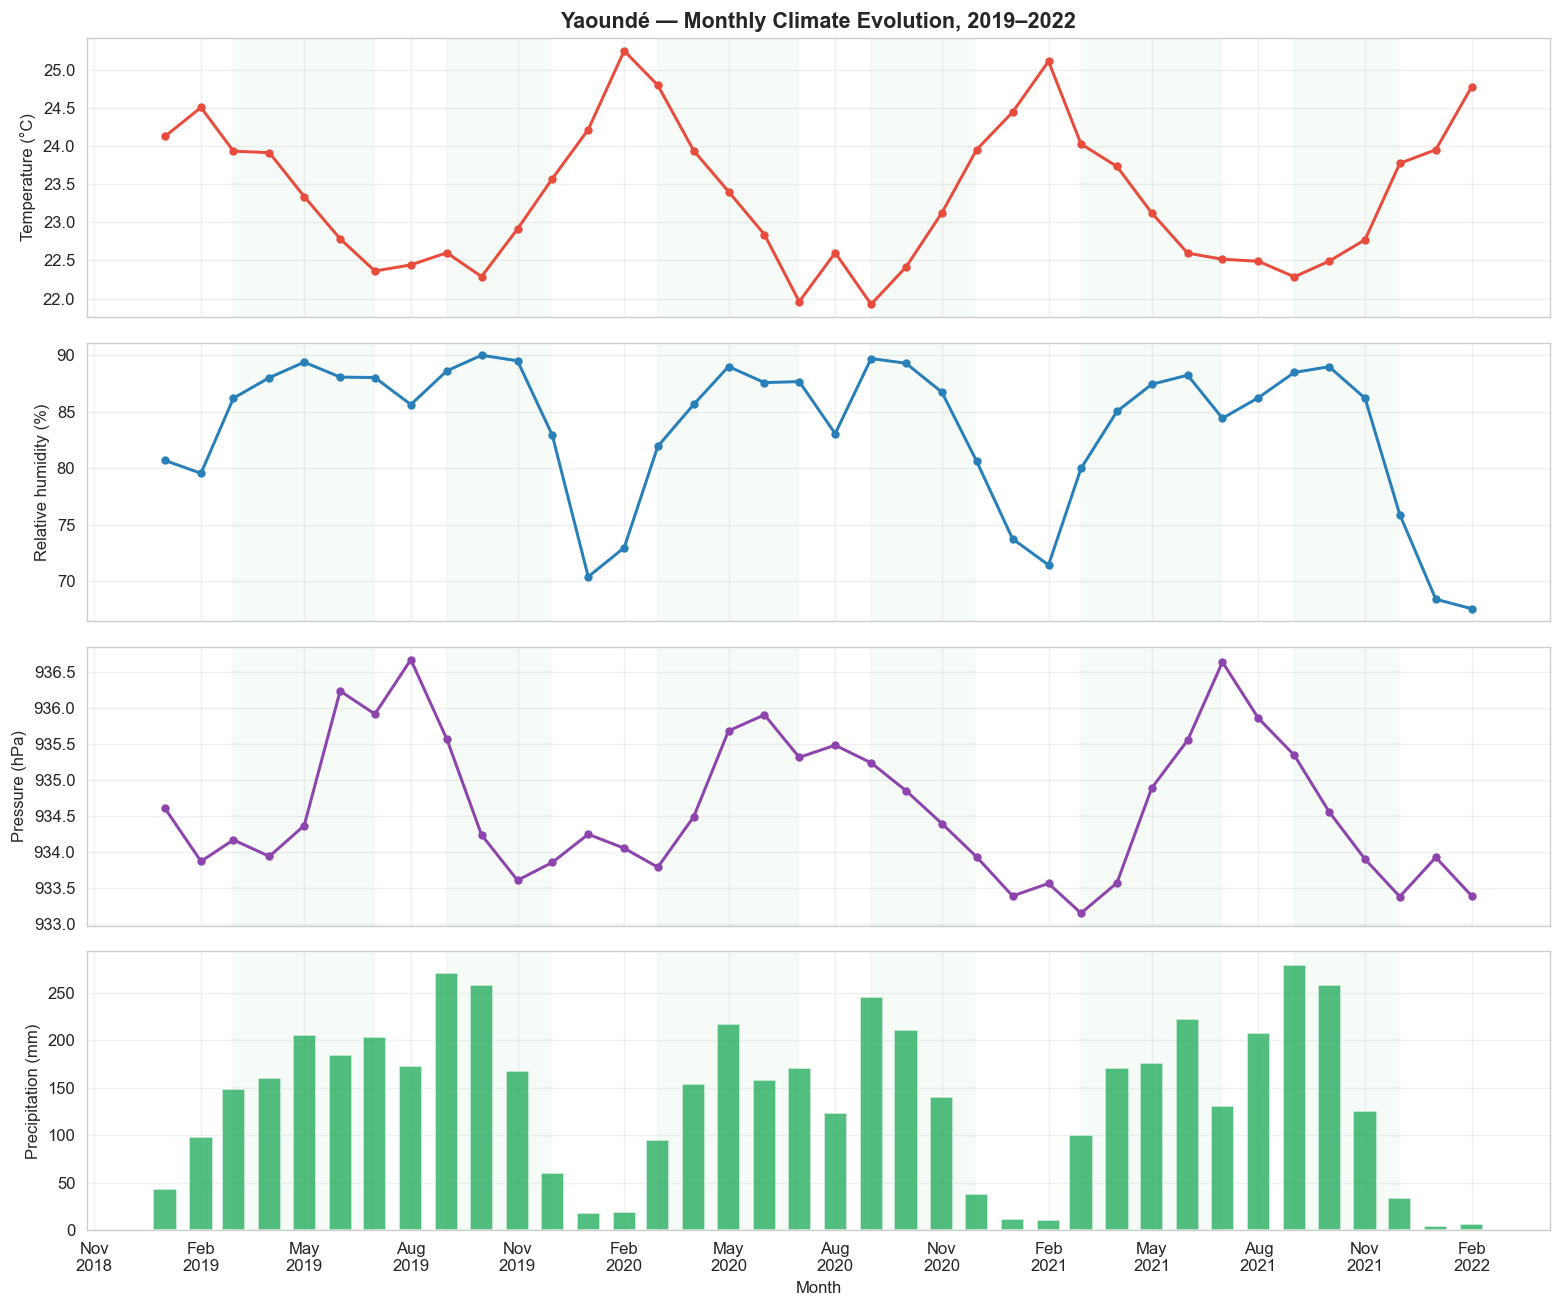

[Figure  1] saved → 2_FIGURES\regenerated\yde_climate_2019_2022.png   — training-period climate


In [7]:
# ══ THESIS FIGURE 1 · yde_climate_2019_2022.png ═════════════════════════════
# Monthly evolution of the four environmental variables, training period.
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
for ax, v in zip(axes, VARS_ORDER):
    if v == 'Precipitation_mm':
        ax.bar(yde_monthly['Date'], yde_monthly[v], width=20,
               color=VARC[v], alpha=0.8, label=VARLAB[v])
    else:
        ax.plot(yde_monthly['Date'], yde_monthly[v], '-o',
                color=VARC[v], ms=4, lw=1.8, label=VARLAB[v])
    ax.set_ylabel(VARLAB[v]); ax.grid(True, alpha=0.3)
    # shade the two rainy seasons (Mar–Jun, Sep–Nov) to guide the eye
    for yr in [2019, 2020, 2021]:
        ax.axvspan(pd.Timestamp(f'{yr}-03-01'), pd.Timestamp(f'{yr}-06-30'),
                   color='#27ae60', alpha=0.04)
        ax.axvspan(pd.Timestamp(f'{yr}-09-01'), pd.Timestamp(f'{yr}-11-30'),
                   color='#27ae60', alpha=0.04)
axes[0].set_title('Yaoundé — Monthly Climate Evolution, 2019–2022',
                  fontsize=13, fontweight='bold')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[-1].set_xlabel('Month')
plt.tight_layout()
save_fig('yde_climate_2019_2022.png', 1, '— training-period climate')

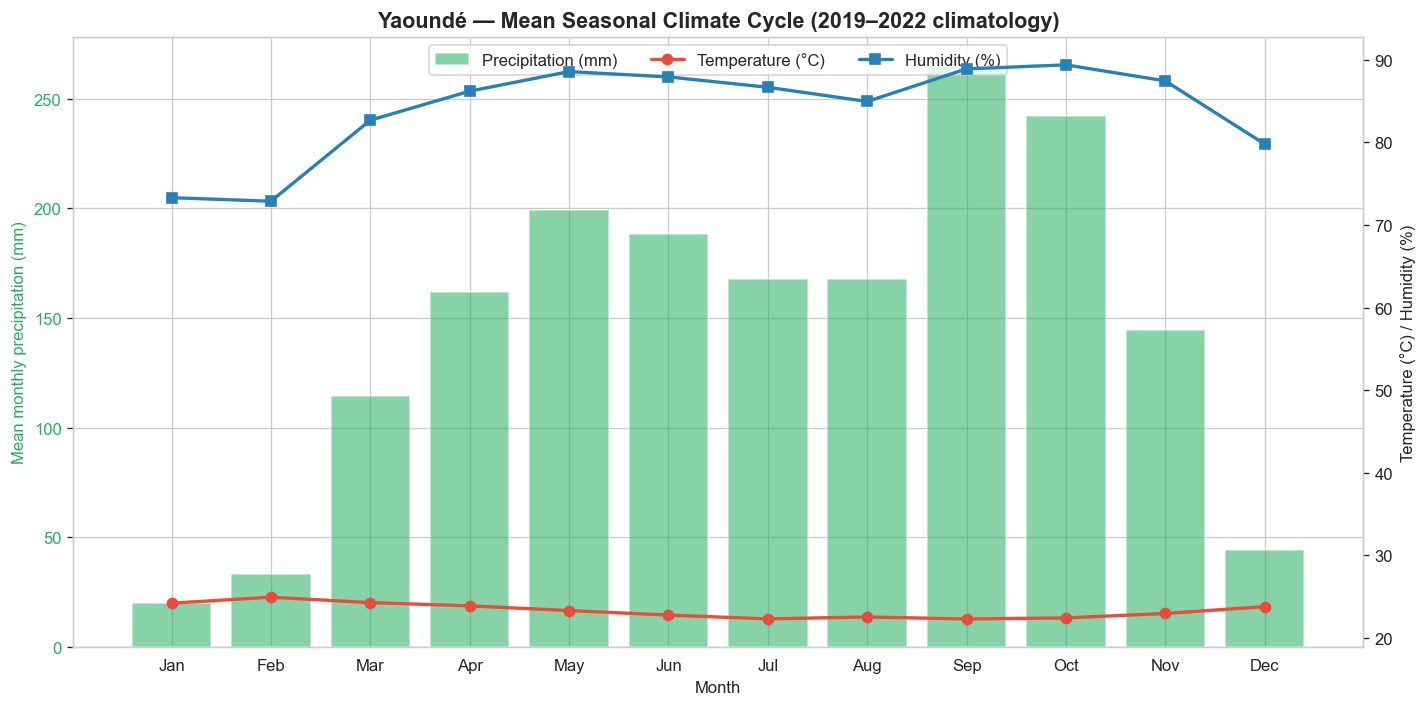

[Figure  2] saved → 2_FIGURES\regenerated\yde_climatology.png   — bimodal peaks: months [9, 10]


In [8]:
# ══ THESIS FIGURE 2 · yde_climatology.png ═══════════════════════════════════
# Mean seasonal cycle: exposes the bimodal rainfall regime.
clim = yde_monthly.copy()
clim['month'] = clim['Date'].dt.month
season = clim.groupby('month').agg(
    Temperature_C=('Temperature_C', 'mean'),
    Humidity=('Humidity', 'mean'),
    Precipitation_mm=('Precipitation_mm', 'mean')).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(season['month'], season['Precipitation_mm'],
        color=VARC['Precipitation_mm'], alpha=0.55, label='Precipitation (mm)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Mean monthly precipitation (mm)', color=VARC['Precipitation_mm'])
ax1.set_xticks(range(1, 13)); ax1.set_xticklabels(MONTH_NAMES)
ax1.tick_params(axis='y', labelcolor=VARC['Precipitation_mm'])

ax2 = ax1.twinx()
ax2.plot(season['month'], season['Temperature_C'], '-o',
         color=VARC['Temperature_C'], lw=2, label='Temperature (°C)')
ax2.plot(season['month'], season['Humidity'], '-s',
         color=VARC['Humidity'], lw=2, label='Humidity (%)')
ax2.set_ylabel('Temperature (°C) / Humidity (%)')
ax2.grid(False)

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc='upper center', ncol=3, frameon=True)
plt.title('Yaoundé — Mean Seasonal Climate Cycle (2019–2022 climatology)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('yde_climatology.png', 2,
         f"— bimodal peaks: months {season.nlargest(2,'Precipitation_mm')['month'].tolist()}")

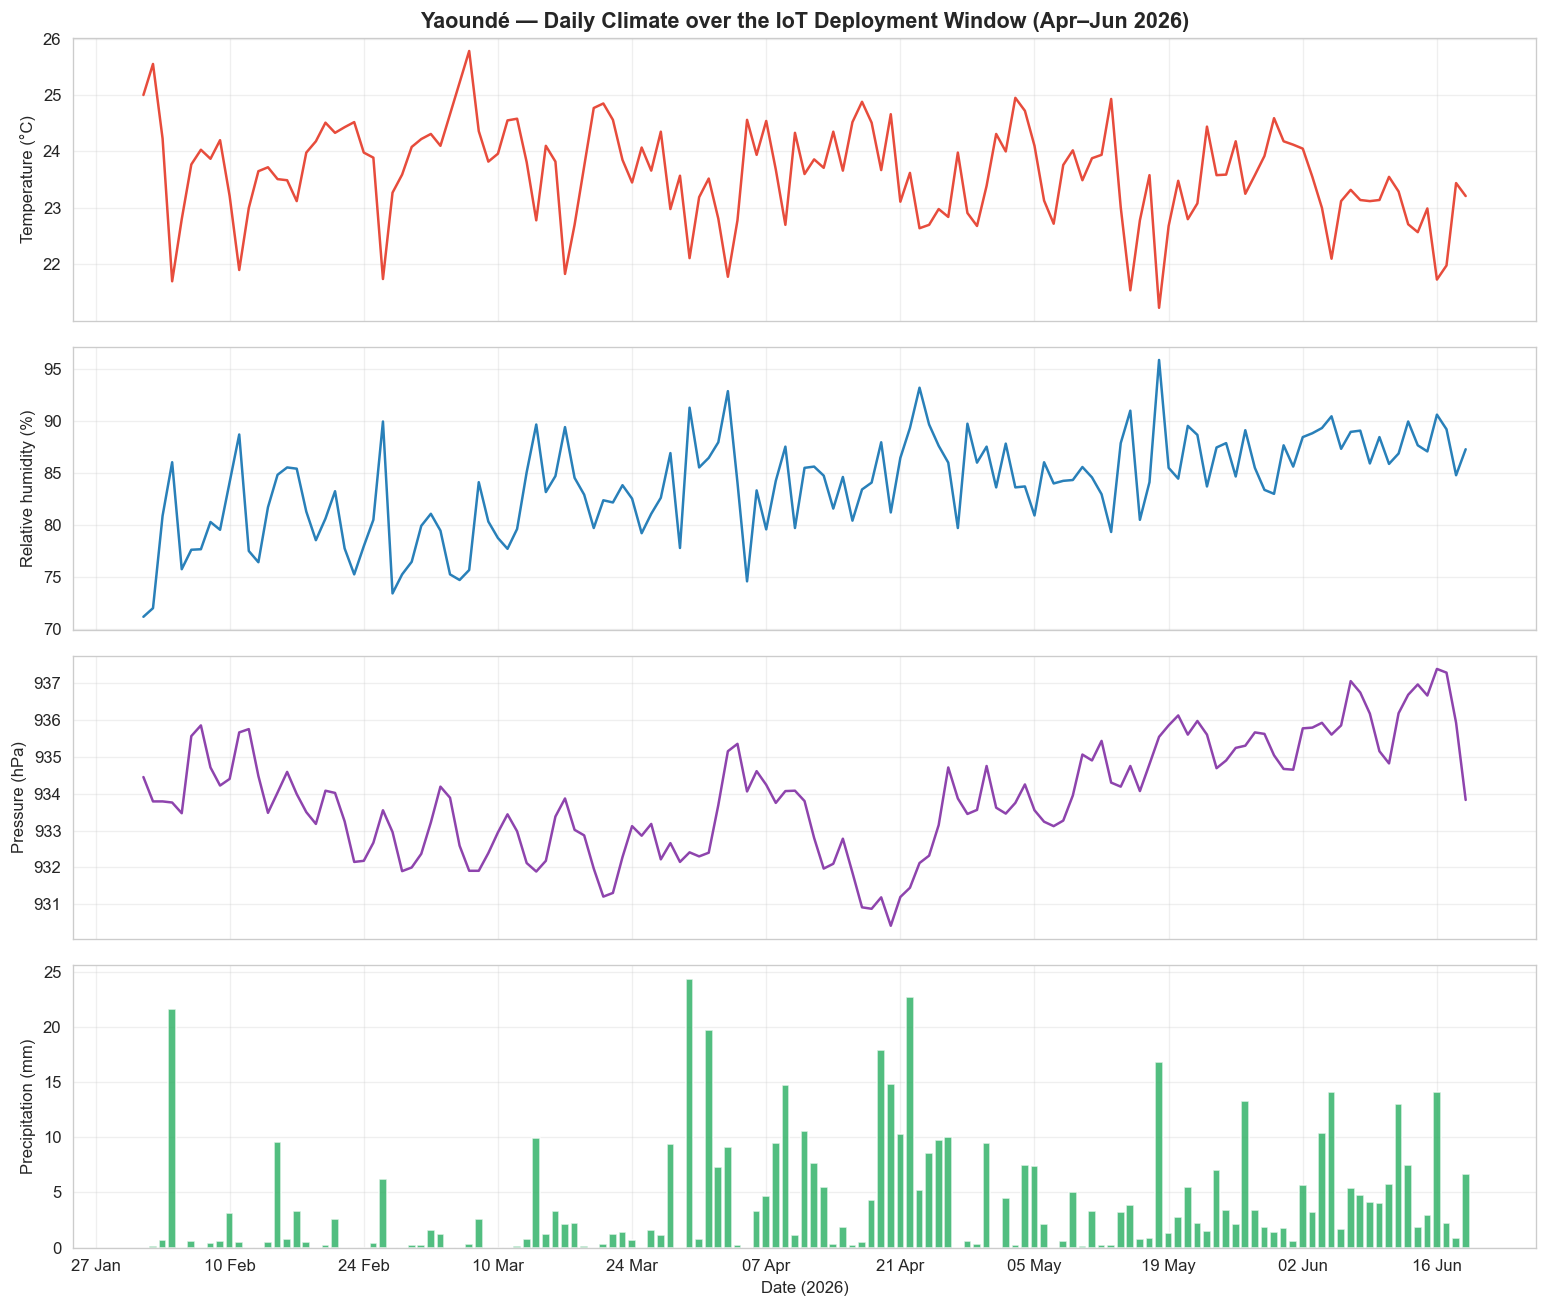

[Figure  3] saved → 2_FIGURES\regenerated\yde_climate_2026.png   — deployment-window climate


In [9]:
# ══ THESIS FIGURE 3 · yde_climate_2026.png ══════════════════════════════════
# Daily evolution over the IoT deployment window.
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
for ax, v in zip(axes, VARS_ORDER):
    if v == 'Precipitation_mm':
        ax.bar(dep['Date'], dep[v], width=0.8, color=VARC[v], alpha=0.8)
    else:
        ax.plot(dep['Date'], dep[v], '-', color=VARC[v], lw=1.5)
    ax.set_ylabel(VARLAB[v]); ax.grid(True, alpha=0.3)
axes[0].set_title('Yaoundé — Daily Climate over the IoT Deployment Window '
                  '(Apr–Jun 2026)', fontsize=13, fontweight='bold')
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].set_xlabel('Date (2026)')
plt.tight_layout()
save_fig('yde_climate_2026.png', 3, '— deployment-window climate')

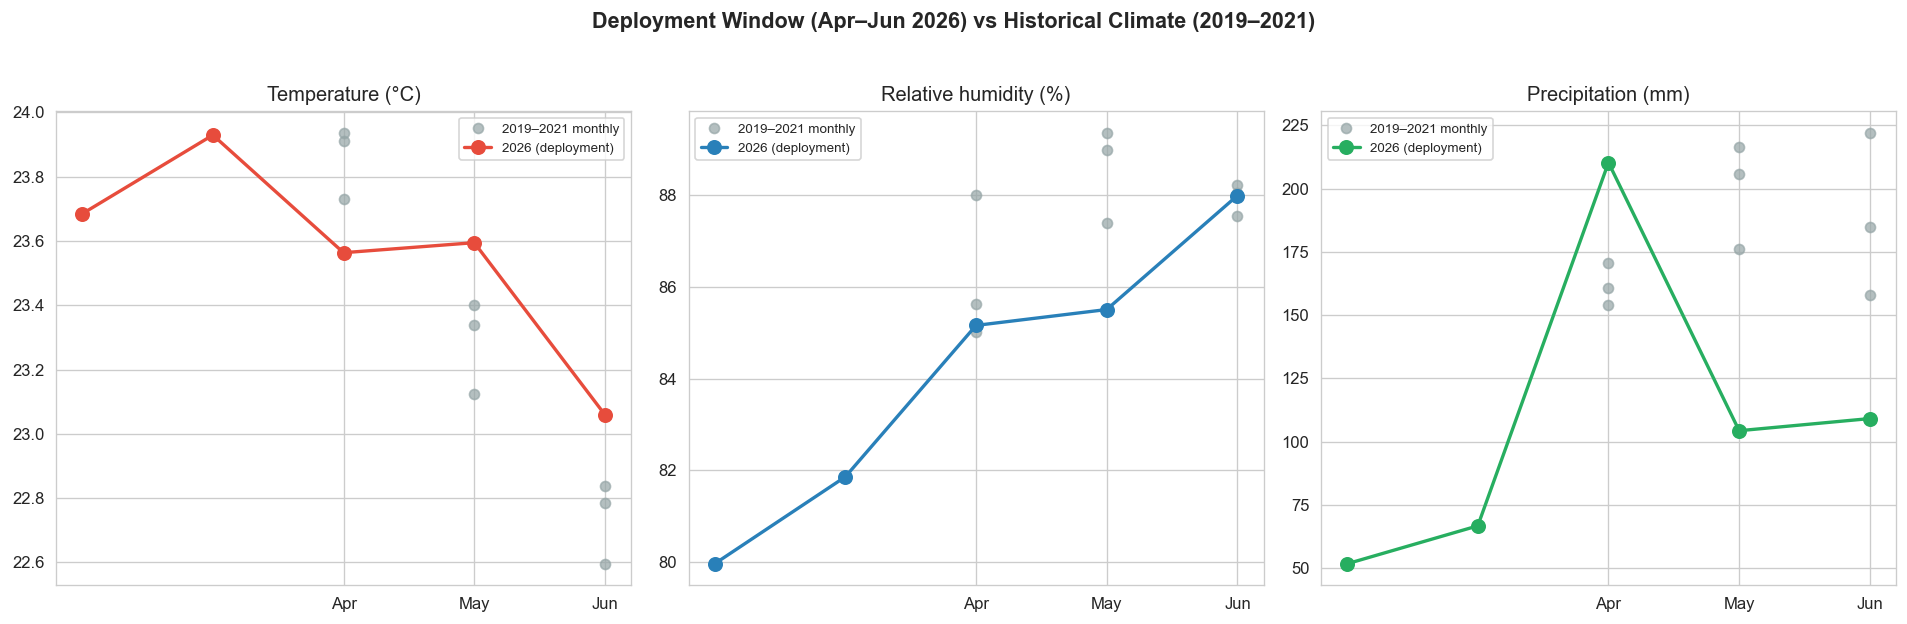

[Figure  4] saved → 2_FIGURES\regenerated\yde_2026_vs_hist.png   — 2026 vs historical envelope


In [10]:
# ══ THESIS FIGURE 4 · yde_2026_vs_hist.png ══════════════════════════════════
# Deployment window against the 2019–2021 historical envelope for Apr/May/Jun.
hist_amj = yde_monthly[yde_monthly['Date'].dt.month.isin([4, 5, 6])]
dep_m = dep.copy(); dep_m['month'] = dep_m['Date'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, v in zip(axes, ['Temperature_C', 'Humidity', 'Precipitation_mm']):
    for m in [4, 5, 6]:
        hv = hist_amj[hist_amj['Date'].dt.month == m][v]
        ax.plot([m] * len(hv), hv, marker='o', linestyle='None',
                color='#95a5a6', alpha=0.7, ms=6,
                label='2019–2021 monthly' if m == 4 else '')
    dep_month = (dep_m.groupby('month')[v].sum() if v == 'Precipitation_mm'
                 else dep_m.groupby('month')[v].mean())
    ax.plot(dep_month.index, dep_month.values, '-o', color=VARC[v], lw=2, ms=8,
            label='2026 (deployment)')
    ax.set_xticks([4, 5, 6]); ax.set_xticklabels(['Apr', 'May', 'Jun'])
    ax.set_title(VARLAB[v]); ax.legend(fontsize=8)
plt.suptitle('Deployment Window (Apr–Jun 2026) vs Historical Climate (2019–2021)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
save_fig('yde_2026_vs_hist.png', 4, '— 2026 vs historical envelope')

---
## Part 3 · Exploratory analysis — the malaria target and the risk threshold

*Thesis Figures 5–10 · originally `te/yaounde_target_eda.ipynb`*

The prediction target itself, again in Yaoundé: monthly cases, the
population-normalised incidence, the per-region 75th-percentile risk threshold
that defines the binary `high` label, and the delayed relationship between
rainfall and incidence that motivates the lagged climate features.

In [11]:
# ── Yaoundé slice of the fused panel ────────────────────────────────────────
sub  = panel[panel['district'].isin(YDE_DISTRICTS)].copy().sort_values(['district','date'])
THR  = sub['threshold_75'].iloc[0]          # Centre-region 75th-pct incidence
DCOL = {'Biyem Assi': '#e74c3c', 'Efoulan': '#2980b9', 'Nkolndongo': '#27ae60'}

# City aggregate, used by Figures 8 and 9
city = sub.groupby('date').agg(cases=('cases', 'sum'), pop=('p_totale', 'sum'),
                               precip=('Precipitation_mm', 'mean'),
                               temp=('Temperature_C', 'mean'),
                               humid=('Humidity_pct', 'mean')).reset_index()
city['incidence'] = city['cases'] / city['pop'] * 1000

print(f'Yaoundé districts : {YDE_DISTRICTS}')
print(f'Centre-region threshold (75th pct incidence): {THR:.2f} per 1000')
print(f'High district-months: {int(sub.high.sum())}/{len(sub)}')

Yaoundé districts : ['Biyem Assi', 'Efoulan', 'Nkolndongo']
Centre-region threshold (75th pct incidence): 14.28 per 1000
High district-months: 18/114


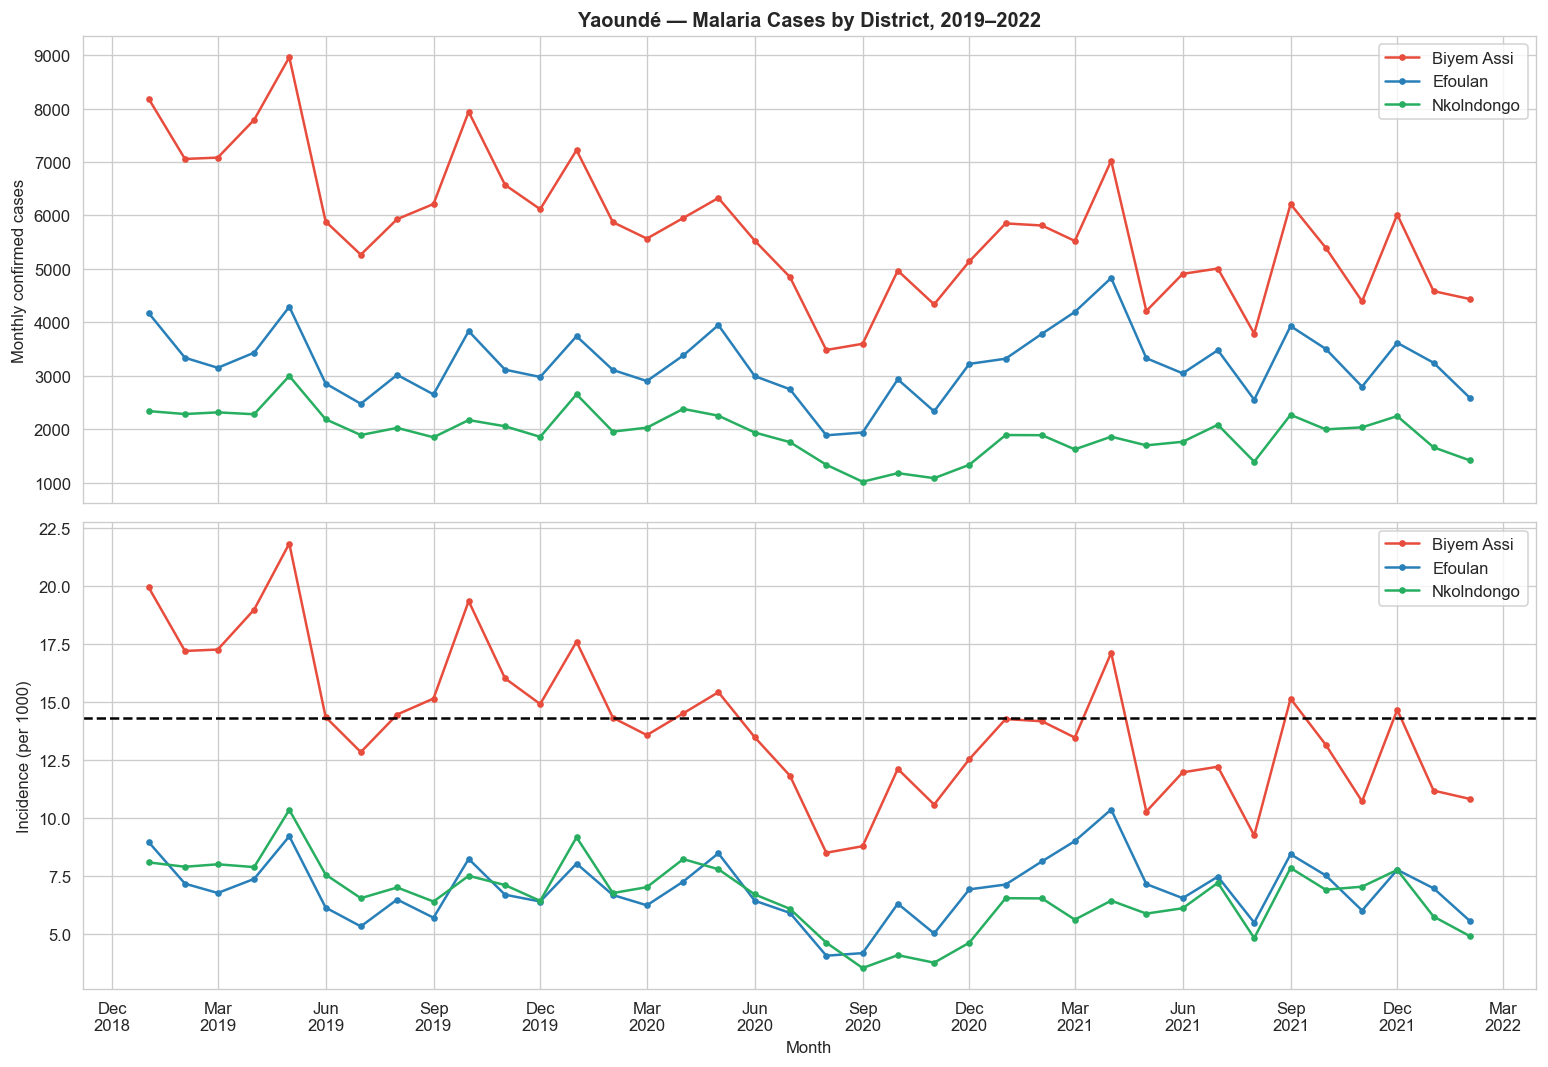

[Figure  5] saved → 2_FIGURES\regenerated\yde_target_districts.png   — cases & incidence per district


In [12]:
# ══ THESIS FIGURE 5 · yde_target_districts.png ══════════════════════════════
# Monthly cases (top) and population-normalised incidence (bottom) per district.
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for d in YDE_DISTRICTS:
    s = sub[sub.district == d]
    axes[0].plot(s.date, s.cases,          '-o', ms=3, color=DCOL[d], label=d)
    axes[1].plot(s.date, s.incidence_rate, '-o', ms=3, color=DCOL[d], label=d)
axes[0].set_ylabel('Monthly confirmed cases')
axes[0].set_title('Yaoundé — Malaria Cases by District, 2019–2022', fontweight='bold')
axes[0].legend()
axes[1].set_ylabel('Incidence (per 1000)'); axes[1].legend()
axes[1].axhline(THR, color='black', ls='--', lw=1.5, label=f'threshold = {THR:.1f}')
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[1].set_xlabel('Month')
plt.tight_layout()
save_fig('yde_target_districts.png', 5, '— cases & incidence per district')

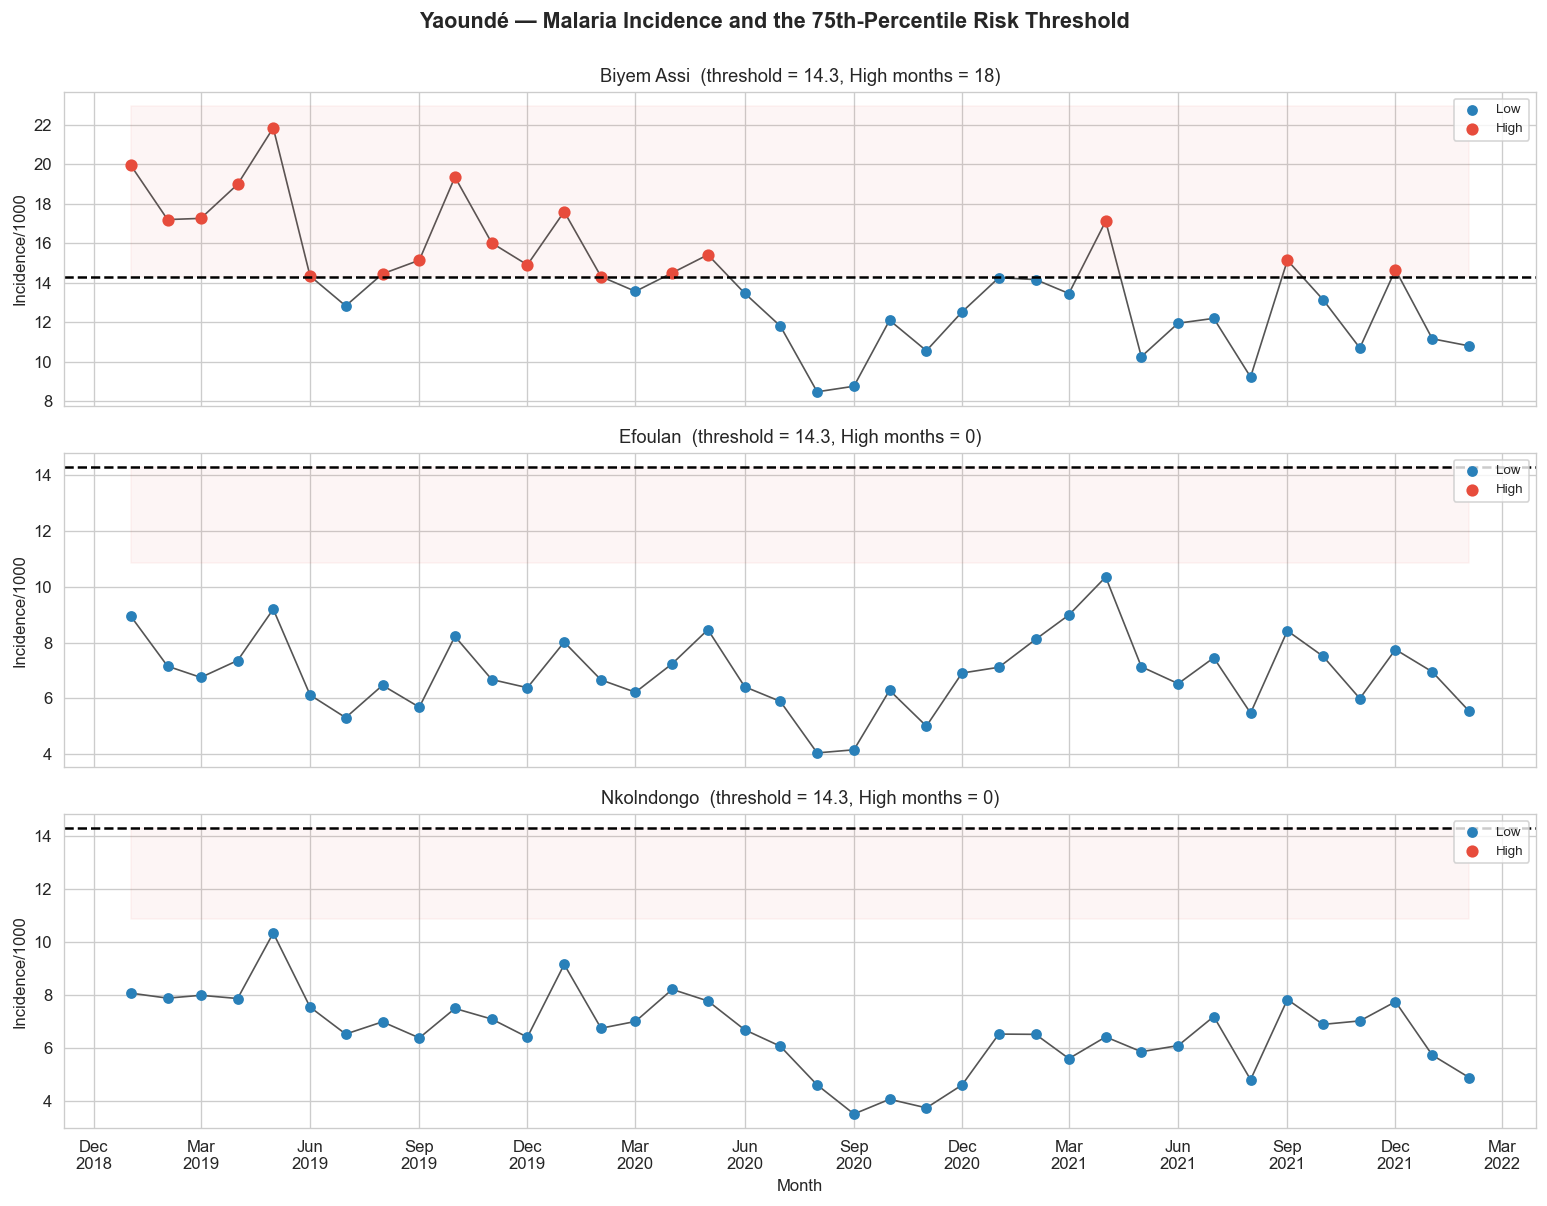

[Figure  6] saved → 2_FIGURES\regenerated\yde_target_threshold.png   — Low/High months vs threshold


In [13]:
# ══ THESIS FIGURE 6 · yde_target_threshold.png ══════════════════════════════
# The classification target made concrete: Low vs High district-months.
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, d in zip(axes, YDE_DISTRICTS):
    s = sub[sub.district == d]
    high = s.incidence_rate > THR
    ax.plot(s.date, s.incidence_rate, '-', color='#555', lw=1, zorder=1)
    ax.scatter(s.date[~high], s.incidence_rate[~high], color='#2980b9', s=30,
               label='Low', zorder=2)
    ax.scatter(s.date[high],  s.incidence_rate[high],  color='#e74c3c', s=40,
               label='High', zorder=2)
    ax.axhline(THR, color='black', ls='--', lw=1.5)
    ax.fill_between(s.date, THR, s.incidence_rate.max() * 1.05,
                    color='#e74c3c', alpha=0.05)
    ax.set_ylabel('Incidence/1000')
    ax.set_title(f'{d}  (threshold = {THR:.1f}, High months = {int(high.sum())})',
                 fontsize=11)
    ax.legend(loc='upper right', fontsize=8)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[-1].set_xlabel('Month')
plt.suptitle('Yaoundé — Malaria Incidence and the 75th-Percentile Risk Threshold',
             fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
save_fig('yde_target_threshold.png', 6, '— Low/High months vs threshold')

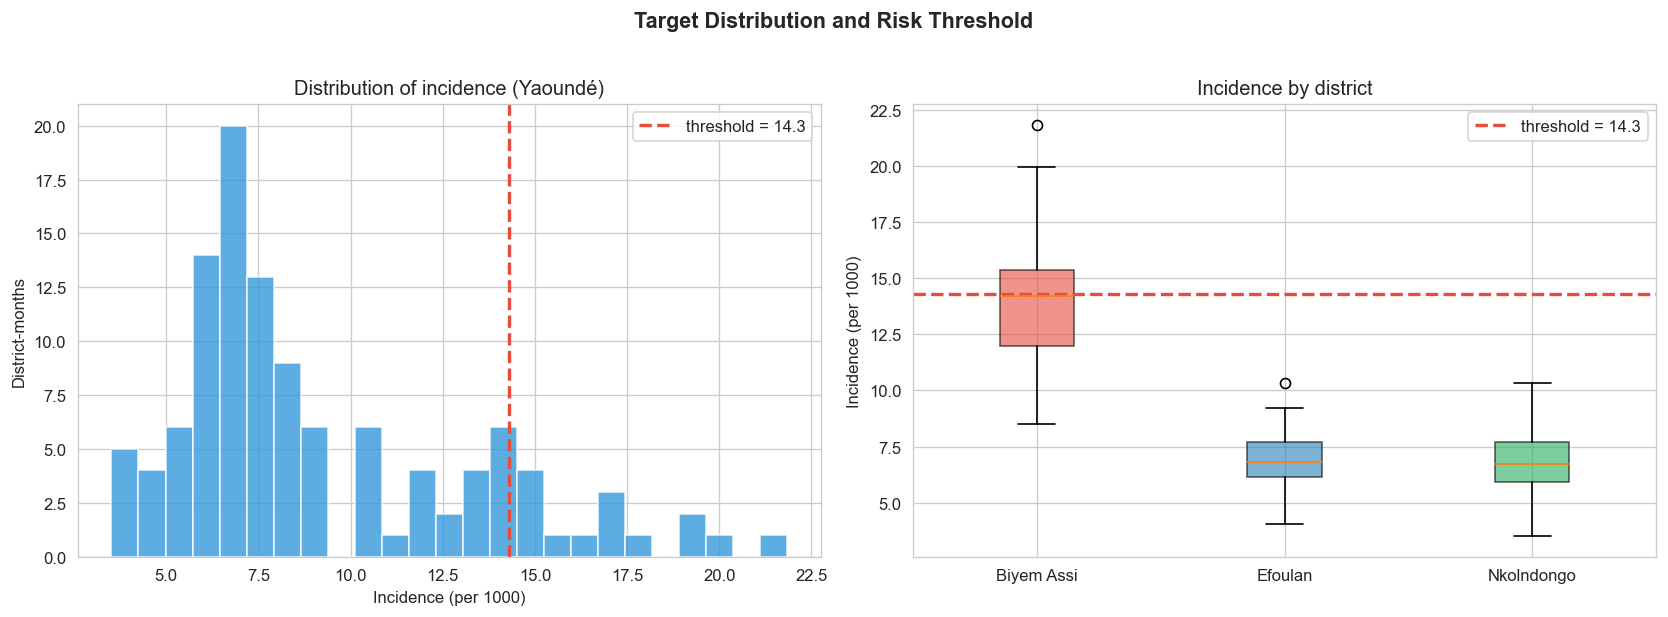

[Figure  7] saved → 2_FIGURES\regenerated\yde_target_distribution.png   — histogram + boxplot vs threshold


In [14]:
# ══ THESIS FIGURE 7 · yde_target_distribution.png ═══════════════════════════
# Where the 75th-percentile threshold sits in the incidence distribution.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(sub.incidence_rate, bins=25, color='#3498db', alpha=0.8,
             edgecolor='white')
axes[0].axvline(THR, color='#e74c3c', ls='--', lw=2, label=f'threshold = {THR:.1f}')
axes[0].set_xlabel('Incidence (per 1000)'); axes[0].set_ylabel('District-months')
axes[0].set_title('Distribution of incidence (Yaoundé)'); axes[0].legend()

data_box = [sub[sub.district == d].incidence_rate.values for d in YDE_DISTRICTS]
try:                     # matplotlib >= 3.9
    bp = axes[1].boxplot(data_box, tick_labels=YDE_DISTRICTS, patch_artist=True)
except TypeError:        # matplotlib < 3.9 (the source notebook's version)
    bp = axes[1].boxplot(data_box, labels=YDE_DISTRICTS, patch_artist=True)
for patch, d in zip(bp['boxes'], YDE_DISTRICTS):
    patch.set_facecolor(DCOL[d]); patch.set_alpha(0.6)
axes[1].axhline(THR, color='#e74c3c', ls='--', lw=2, label=f'threshold = {THR:.1f}')
axes[1].set_ylabel('Incidence (per 1000)'); axes[1].set_title('Incidence by district')
axes[1].legend()
plt.suptitle('Target Distribution and Risk Threshold', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('yde_target_distribution.png', 7, '— histogram + boxplot vs threshold')

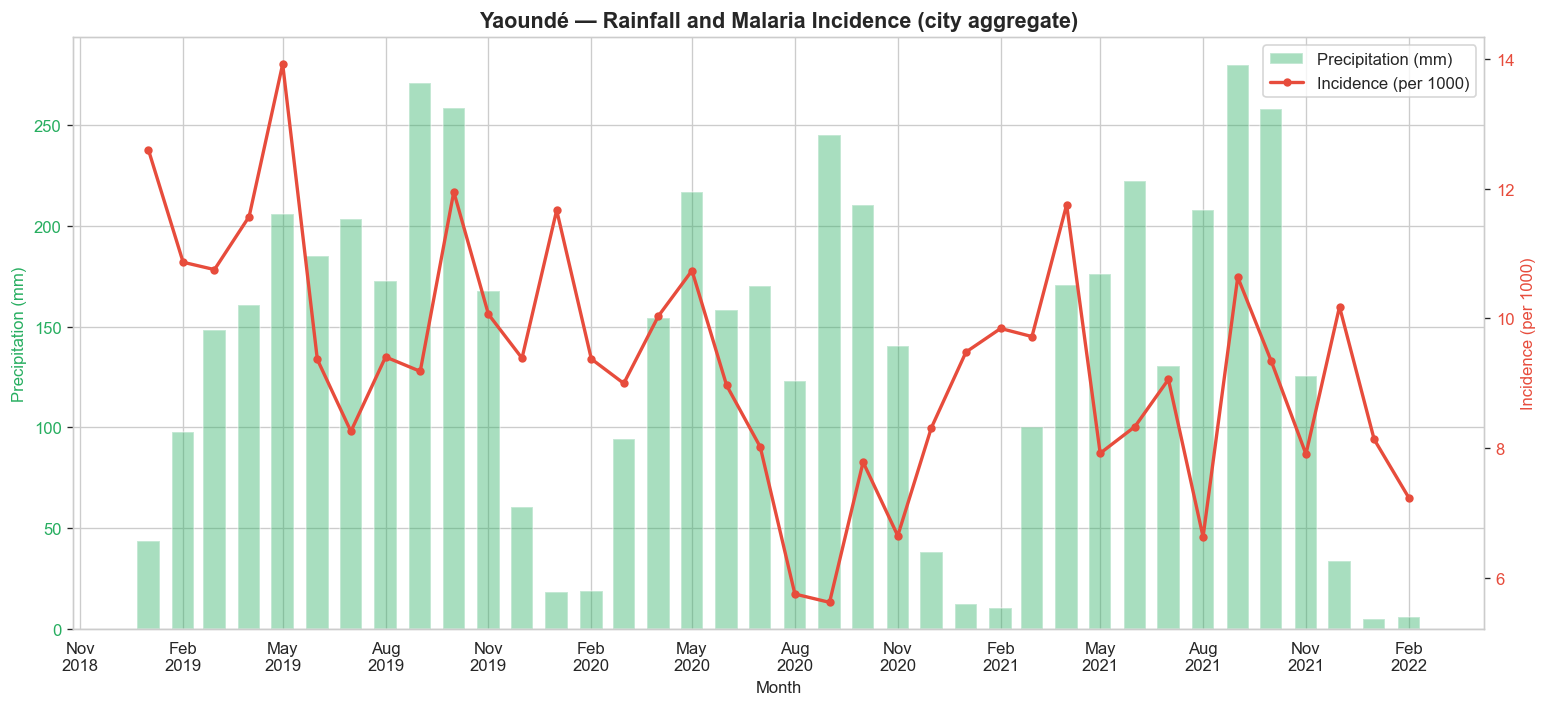

[Figure  8] saved → 2_FIGURES\regenerated\yde_climate_malaria.png   — rainfall / incidence overlay


In [15]:
# ══ THESIS FIGURE 8 · yde_climate_malaria.png ═══════════════════════════════
# Rainfall vs incidence: the response is delayed, not simultaneous.
fig, ax1 = plt.subplots(figsize=(13, 6))
ax1.bar(city.date, city.precip, width=20, color='#27ae60', alpha=0.4,
        label='Precipitation (mm)')
ax1.set_ylabel('Precipitation (mm)', color='#27ae60')
ax1.tick_params(axis='y', labelcolor='#27ae60')

ax2 = ax1.twinx()
ax2.plot(city.date, city.incidence, '-o', color='#e74c3c', ms=4, lw=2,
         label='Incidence (per 1000)')
ax2.set_ylabel('Incidence (per 1000)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.grid(False)

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax1.set_xlabel('Month')
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc='upper right')
plt.title('Yaoundé — Rainfall and Malaria Incidence (city aggregate)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('yde_climate_malaria.png', 8, '— rainfall / incidence overlay')

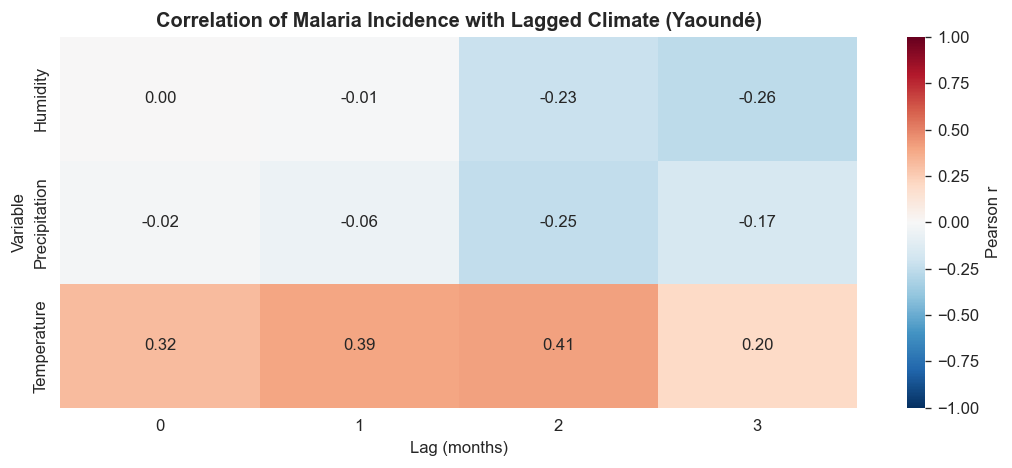

[Figure  9] saved → 2_FIGURES\regenerated\yde_lag_correlation.png   — lagged climate–incidence correlation


Lag (months),0,1,2,3
Variable,,,,
Humidity,0.00,-0.01,-0.23,-0.26
Precipitation,-0.02,-0.06,-0.25,-0.17
Temperature,0.32,0.39,0.41,0.20


Note: city-level n is small (38 months); correlations are indicative.


In [16]:
# ══ THESIS FIGURE 9 · yde_lag_correlation.png ═══════════════════════════════
# Correlation of incidence with each climate variable at lags 0–3 months.
c = city.sort_values('date').reset_index(drop=True)
vars_ = {'precip': 'Precipitation', 'temp': 'Temperature', 'humid': 'Humidity'}
rows = [{'Variable': lab, 'Lag (months)': L,
         'Correlation': c['incidence'].corr(c[v].shift(L))}
        for v, lab in vars_.items() for L in [0, 1, 2, 3]]
piv = pd.DataFrame(rows).pivot(index='Variable', columns='Lag (months)',
                               values='Correlation')

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(piv, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation of Malaria Incidence with Lagged Climate (Yaoundé)',
             fontweight='bold')
plt.tight_layout()
save_fig('yde_lag_correlation.png', 9, '— lagged climate–incidence correlation')
display(piv.round(2))
print('Note: city-level n is small (38 months); correlations are indicative.')

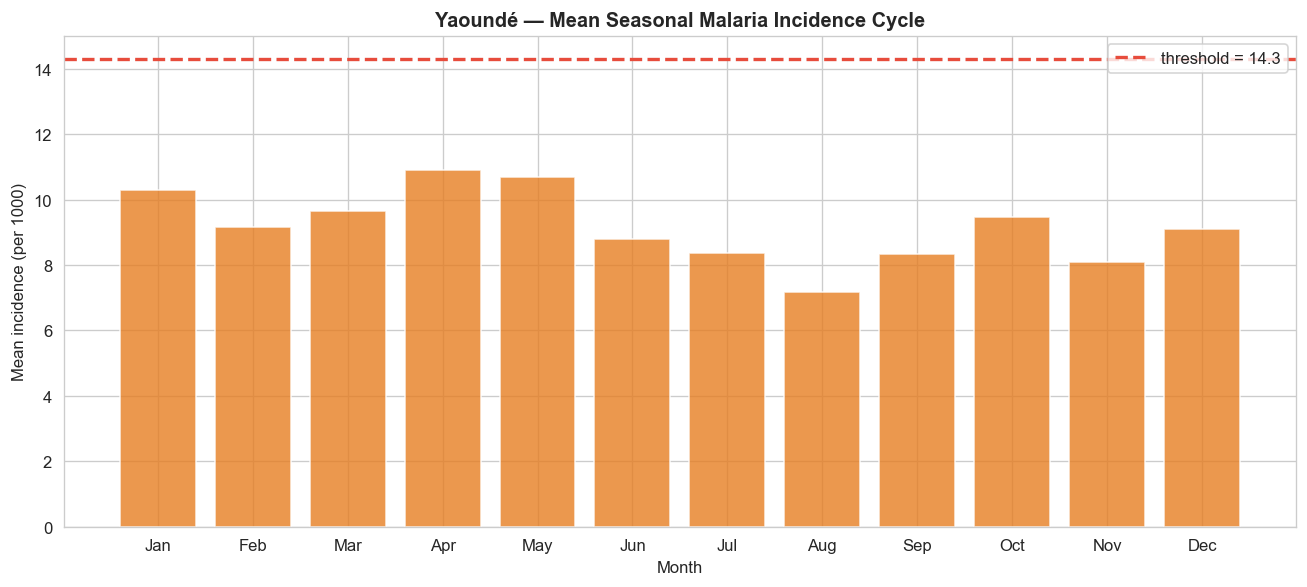

[Figure 10] saved → 2_FIGURES\regenerated\yde_seasonal_cases.png   — seasonal incidence cycle


In [17]:
# ══ THESIS FIGURE 10 · yde_seasonal_cases.png ═══════════════════════════════
# Mean seasonal cycle of the incidence, mirroring the rainfall climatology.
sub = sub.copy(); sub['month'] = sub['date'].dt.month
season_inc = sub.groupby('month').agg(incidence=('incidence_rate', 'mean')).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(season_inc.month, season_inc.incidence, color='#e67e22', alpha=0.8,
       edgecolor='white')
ax.axhline(THR, color='#e74c3c', ls='--', lw=2, label=f'threshold = {THR:.1f}')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Mean incidence (per 1000)'); ax.set_xlabel('Month')
ax.set_title('Yaoundé — Mean Seasonal Malaria Incidence Cycle', fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('yde_seasonal_cases.png', 10, '— seasonal incidence cycle')

---
## Part 4 · Modelling results — three feature regimes and the honesty envelope

*Thesis Figures 11–17 (`fig1`–`fig7`) · originally `files (2)/malaria_showcase_lag.ipynb`*

The results chapter is built on three nested feature regimes evaluated on the
same 6 895 district-months:

| Regime | Features | Question |
|---|---|---|
| **RAW** | 5 — month + 4 raw climate variables | can raw climate alone predict malaria? |
| **RAW+ENG** | 16 — + seasonal encoding, geography, climate lags | how much does feature engineering add? |
| **+lag_cases** | 20 — + `cases_lag1/2/3`, `rolling_mean_3m` | what is the ceiling with case history? |

The caveat carried throughout: `cases_lag` features are strongly predictive but
require case history that a sensor-only deployment does not have. Figure 17
stress-tests that by feeding the model its own predictions.

> **Runtime warning.** Figure 12 trains 12 classifiers × 2 CV schemes × 5 folds,
> including `SVC(probability=True)` and an MLP on 6 895 rows. Measured at ~8.5
> minutes for that cell alone; it prints per-model progress as it goes.

In [18]:
# ── Shared modelling helpers for Part 4 ─────────────────────────────────────
REGIMES = [('RAW', FEAT_RAW), ('RAW+ENG', FEAT_ENG), ('+lag_cases', FEAT_LAG)]


def _X(F):
    """Feature matrix for a regime, median-imputed."""
    return dfm[F].fillna(dfm[F].median())


def cv_r2(F, splitter):
    """Mean R² of the reference XGBoost regressor on log_incidence."""
    X, y = _X(F), dfm['log_incidence']
    scores = []
    for tr, te in splitter.split(X):
        m = make_xgb_reg(); m.fit(X.iloc[tr], y.iloc[tr])
        scores.append(r2_score(y.iloc[te], m.predict(X.iloc[te])))
    return float(np.mean(scores))


def cv_f1(F, splitter):
    """Mean F1 of the reference XGBoost classifier on `high`."""
    X, y = _X(F), dfm['high']
    splits = (splitter.split(X, y) if isinstance(splitter, StratifiedKFold)
              else splitter.split(X))
    scores = []
    for tr, te in splits:
        if len(np.unique(y.iloc[tr])) < 2 or len(np.unique(y.iloc[te])) < 2:
            continue
        m = make_xgb_clf(SPW); m.fit(X.iloc[tr], y.iloc[tr])
        scores.append(f1_score(y.iloc[te], m.predict(X.iloc[te]), zero_division=0))
    return float(np.mean(scores))


def loro_table(F=FEAT_ENG):
    """Leave-One-Region-Out: train on 9 regions, test on the held-out one.

    Shared by Figures 13 and 15 — the source notebook computed it twice with
    identical hyper-parameters.
    """
    rows = []
    Xall = _X(F)
    for rg in sorted(dfm['region'].unique()):
        te = dfm['region'] == rg
        tr = ~te
        Xtr, Xte = Xall[tr], Xall[te]
        sw = (dfm.loc[tr, 'high'] == 0).sum() / max((dfm.loc[tr, 'high'] == 1).sum(), 1)
        c = make_xgb_clf(sw, n_estimators=200, max_depth=4, learning_rate=0.1)
        c.fit(Xtr, dfm.loc[tr, 'high'])
        f1 = f1_score(dfm.loc[te, 'high'], c.predict(Xte), zero_division=0)
        r = make_xgb_reg(n_estimators=300, max_depth=4)
        r.fit(Xtr, dfm.loc[tr, 'log_incidence'])
        r2 = r2_score(dfm.loc[te, 'log_incidence'], r.predict(Xte))
        rows.append({'Region': rg, 'F1': f1, 'R2': r2})
    return pd.DataFrame(rows)


def all_classifiers():
    """The 12-classifier panel used for the temporal-leakage comparison."""
    return {
        'XGBoost'     : make_xgb_clf(SPW),
        'CatBoost'    : CatBoostClassifier(iterations=300, depth=5, learning_rate=0.05,
                                           auto_class_weights='Balanced',
                                           random_seed=SEED, verbose=0),
        'LightGBM'    : lgb.LGBMClassifier(n_estimators=300, max_depth=5,
                                           learning_rate=0.05, subsample=0.8,
                                           colsample_bytree=0.8, class_weight='balanced',
                                           random_state=SEED, verbose=-1),
        'GradBoost'   : GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                   learning_rate=0.1, random_state=SEED),
        'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=8,
                                               class_weight='balanced',
                                               random_state=SEED, n_jobs=-1),
        'ExtraTrees'  : ExtraTreesClassifier(n_estimators=200, max_depth=8,
                                             class_weight='balanced',
                                             random_state=SEED, n_jobs=-1),
        'DecisionTree': DecisionTreeClassifier(max_depth=8, class_weight='balanced',
                                               random_state=SEED),
        'MLP'         : Pipeline([('sc', StandardScaler()),
                                  ('m', MLPClassifier(hidden_layer_sizes=(64, 32),
                                                      max_iter=500, random_state=SEED))]),
        'SVM'         : Pipeline([('sc', StandardScaler()),
                                  ('m', SVC(kernel='rbf', probability=True,
                                            class_weight='balanced', random_state=SEED))]),
        'LogisticReg' : Pipeline([('sc', StandardScaler()),
                                  ('m', LogisticRegression(class_weight='balanced',
                                                           max_iter=1000, random_state=SEED))]),
        'KNN'         : Pipeline([('sc', StandardScaler()),
                                  ('m', KNeighborsClassifier(n_neighbors=10))]),
        'NaiveBayes'  : Pipeline([('sc', StandardScaler()), ('m', GaussianNB())]),
    }

print('Part 4 helpers ready: cv_r2, cv_f1, loro_table, all_classifiers')

Part 4 helpers ready: cv_r2, cv_f1, loro_table, all_classifiers


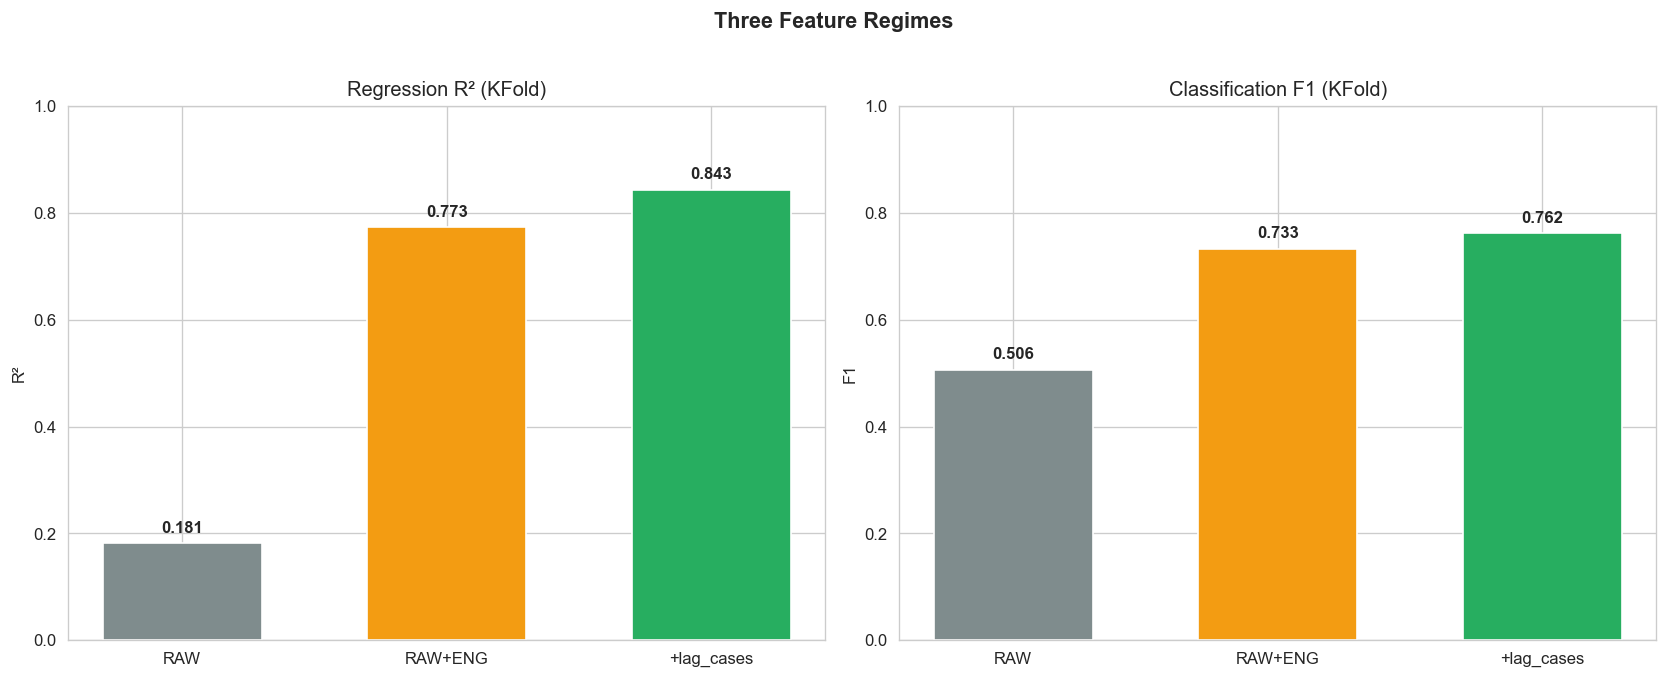

[Figure 11] saved → 2_FIGURES\regenerated\fig1_regimes_lag.png   — three-regime progression
R²: {'RAW': 0.181, 'RAW+ENG': 0.773, '+lag_cases': 0.843}
F1: {'RAW': 0.506, 'RAW+ENG': 0.733, '+lag_cases': 0.762}


In [19]:
# ══ THESIS FIGURE 11 · fig1_regimes_lag.png ═════════════════════════════════
# Stepwise value of each feature group, regression and classification.
names = [r for r, _ in REGIMES]
r2v = [cv_r2(F, KFold(5, shuffle=True, random_state=SEED)) for _, F in REGIMES]
f1v = [cv_f1(F, StratifiedKFold(5, shuffle=True, random_state=SEED)) for _, F in REGIMES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cols = [CLR[n] for n in names]
b1 = axes[0].bar(names, r2v, color=cols, edgecolor='white', width=0.6)
axes[0].set_ylabel('R²'); axes[0].set_ylim(0, 1)
axes[0].set_title('Regression R² (KFold)')
for bar, v in zip(b1, r2v):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
                 ha='center', fontweight='bold')
b2 = axes[1].bar(names, f1v, color=cols, edgecolor='white', width=0.6)
axes[1].set_ylabel('F1'); axes[1].set_ylim(0, 1)
axes[1].set_title('Classification F1 (KFold)')
for bar, v in zip(b2, f1v):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
                 ha='center', fontweight='bold')
plt.suptitle('Three Feature Regimes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fig1_regimes_lag.png', 11, '— three-regime progression')
print('R²:', {n: round(v, 3) for n, v in zip(names, r2v)})
print('F1:', {n: round(v, 3) for n, v in zip(names, f1v)})

  XGBoost       KFold=0.762  TSS=0.691  (15s elapsed)
  CatBoost      KFold=0.737  TSS=0.682  (46s elapsed)
  LightGBM      KFold=0.755  TSS=0.689  (63s elapsed)
  GradBoost     KFold=0.709  TSS=0.629  (210s elapsed)
  RandomForest  KFold=0.658  TSS=0.620  (245s elapsed)
  ExtraTrees    KFold=0.609  TSS=0.578  (275s elapsed)
  DecisionTree  KFold=0.613  TSS=0.566  (278s elapsed)
  MLP           KFold=0.672  TSS=0.528  (789s elapsed)
  SVM           KFold=0.613  TSS=0.512  (999s elapsed)
  LogisticReg   KFold=0.497  TSS=0.453  (1010s elapsed)
  KNN           KFold=0.496  TSS=0.406  (1021s elapsed)
  NaiveBayes    KFold=0.359  TSS=0.339  (1022s elapsed)


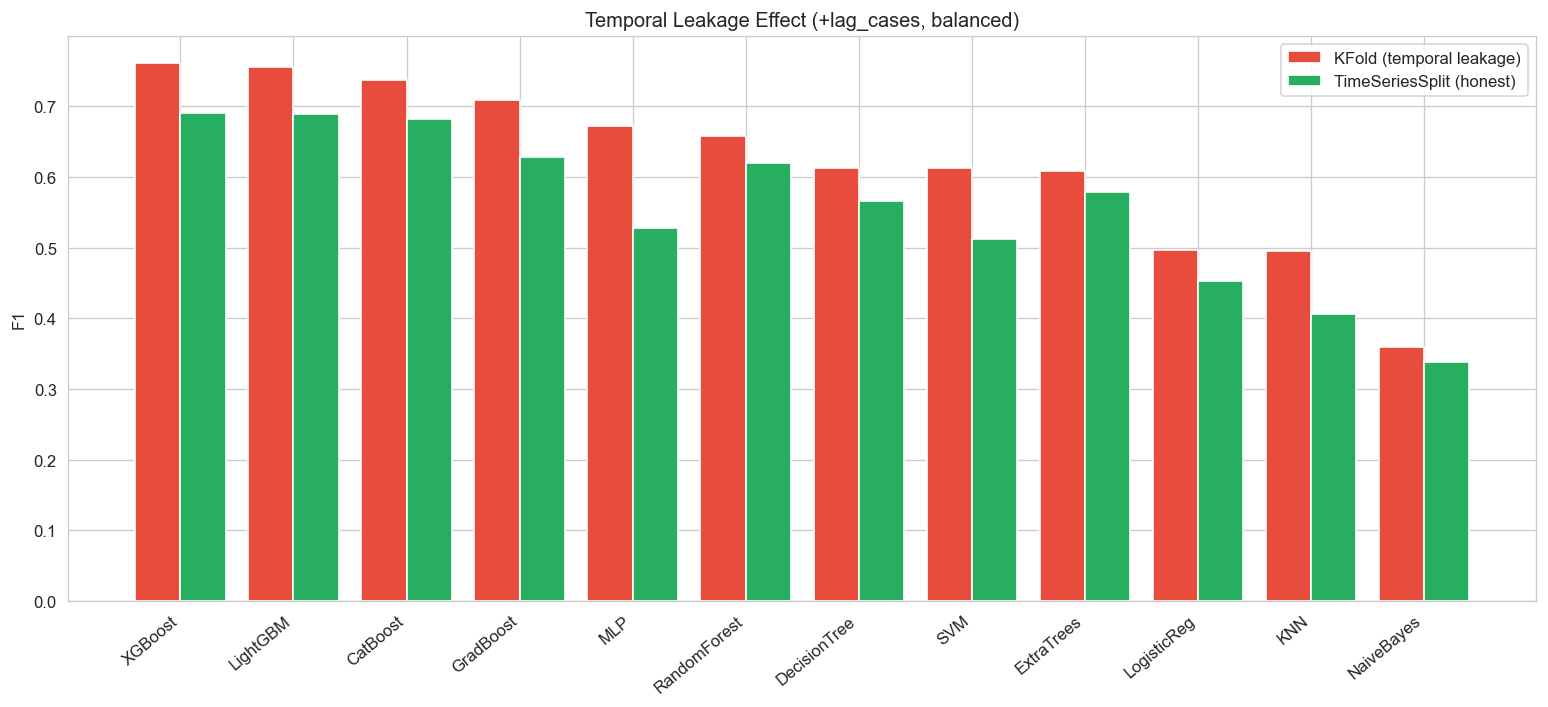

[Figure 12] saved → 2_FIGURES\regenerated\fig2_temporal_leak_lag.png   — mean leakage gap +0.066 F1


In [20]:
# ══ THESIS FIGURE 12 · fig2_temporal_leak_lag.png ═══════════════════════════
# All 12 classifiers, KFold (leaky) vs TimeSeriesSplit (honest), +lag_cases.
# SLOW CELL — 10-20 minutes.
t0 = time.time()
X, y = _X(FEAT_LAG), dfm['high']
rows = []
for nm, model in all_classifiers().items():
    kf, ts = [], []
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y):
        m = copy.deepcopy(model); m.fit(X.iloc[tr], y.iloc[tr])
        kf.append(f1_score(y.iloc[te], m.predict(X.iloc[te]), zero_division=0))
    for tr, te in TimeSeriesSplit(5).split(X):
        if len(np.unique(y.iloc[tr])) < 2 or len(np.unique(y.iloc[te])) < 2:
            continue
        m = copy.deepcopy(model); m.fit(X.iloc[tr], y.iloc[tr])
        ts.append(f1_score(y.iloc[te], m.predict(X.iloc[te]), zero_division=0))
    rows.append({'Model': nm, 'KFold': np.mean(kf), 'TimeSeriesSplit': np.mean(ts)})
    print(f'  {nm:<13} KFold={np.mean(kf):.3f}  TSS={np.mean(ts):.3f}  '
          f'({time.time()-t0:.0f}s elapsed)')

leak = pd.DataFrame(rows).sort_values('KFold', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(leak)); w = 0.4
ax.bar(x - w/2, leak['KFold'], w, label='KFold (temporal leakage)',
       color=CLR['leak'], edgecolor='white')
ax.bar(x + w/2, leak['TimeSeriesSplit'], w, label='TimeSeriesSplit (honest)',
       color=CLR['honest'], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(leak['Model'], rotation=40, ha='right')
ax.set_ylabel('F1')
ax.set_title('Temporal Leakage Effect (+lag_cases, balanced)')
ax.legend()
plt.tight_layout()
save_fig('fig2_temporal_leak_lag.png', 12,
         f"— mean leakage gap {(leak['KFold']-leak['TimeSeriesSplit']).mean():+.3f} F1")

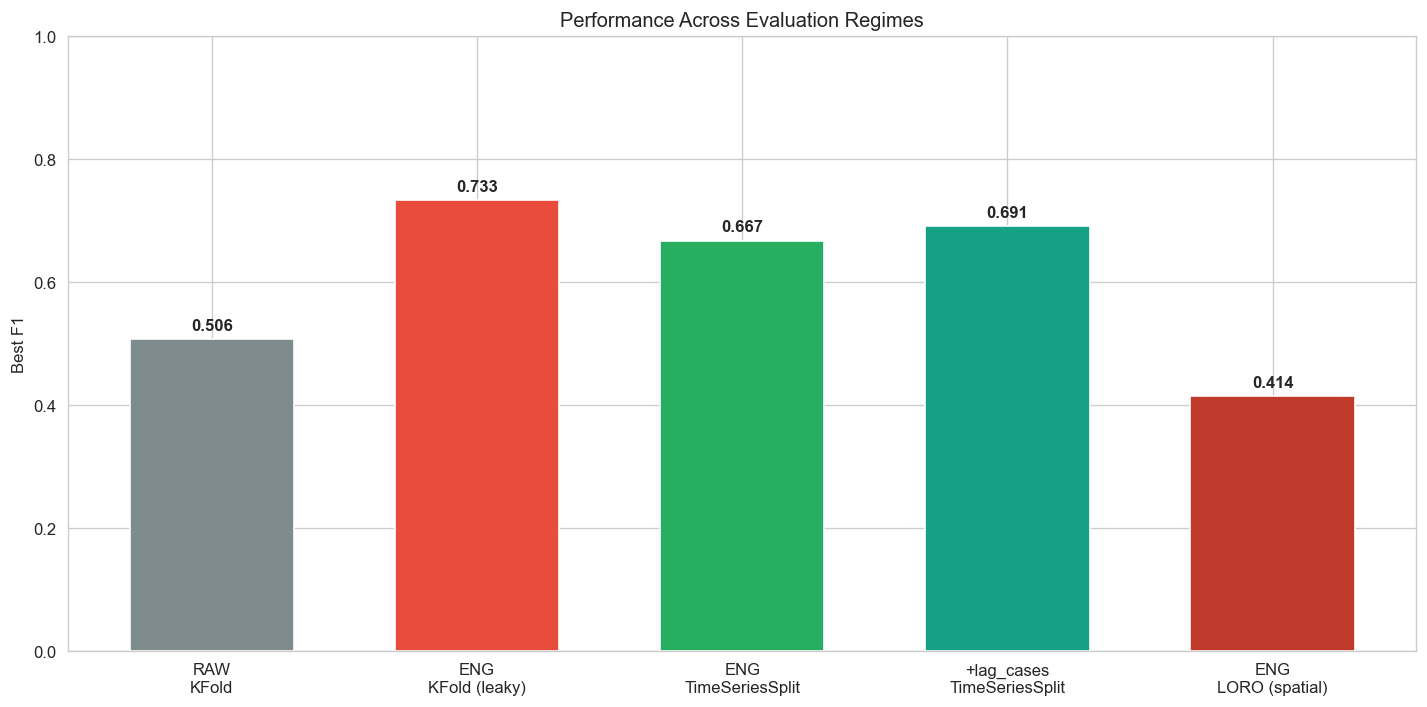

[Figure 13] saved → 2_FIGURES\regenerated\fig3_envelope_lag.png   — validation-regime envelope
Envelope: {'RAW KFold': 0.506, 'ENG KFold (leaky)': 0.733, 'ENG TimeSeriesSplit': 0.667, '+lag_cases TimeSeriesSplit': 0.691, 'ENG LORO (spatial)': 0.414}


In [21]:
# ══ THESIS FIGURE 13 · fig3_envelope_lag.png ════════════════════════════════
# The full honesty envelope: weakest baseline → optimistic → honest → spatial.
raw_kf  = cv_f1(FEAT_RAW, StratifiedKFold(5, shuffle=True, random_state=SEED))
eng_kf  = cv_f1(FEAT_ENG, StratifiedKFold(5, shuffle=True, random_state=SEED))
eng_tss = cv_f1(FEAT_ENG, TimeSeriesSplit(5))
lag_tss = cv_f1(FEAT_LAG, TimeSeriesSplit(5))

loro = loro_table(FEAT_ENG)          # reused by Figure 15
eng_loro = loro['F1'].mean()

labels = ['RAW\nKFold', 'ENG\nKFold (leaky)', 'ENG\nTimeSeriesSplit',
          '+lag_cases\nTimeSeriesSplit', 'ENG\nLORO (spatial)']
vals = [raw_kf, eng_kf, eng_tss, lag_tss, eng_loro]
cols = ['#7f8c8d', '#e74c3c', '#27ae60', '#16a085', '#c0392b']

fig, ax = plt.subplots(figsize=(12, 6))
b = ax.bar(labels, vals, color=cols, edgecolor='white', width=0.62)
ax.set_ylabel('Best F1'); ax.set_ylim(0, 1)
ax.set_title('Performance Across Evaluation Regimes')
for bar, v in zip(b, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, f'{v:.3f}',
            ha='center', fontweight='bold')
plt.tight_layout()
save_fig('fig3_envelope_lag.png', 13, '— validation-regime envelope')
print('Envelope:', {l.replace('\n', ' '): round(v, 3) for l, v in zip(labels, vals)})

  [shap fallback] could not convert string to float: '[2.121477E0]'  → using xgboost pred_contribs


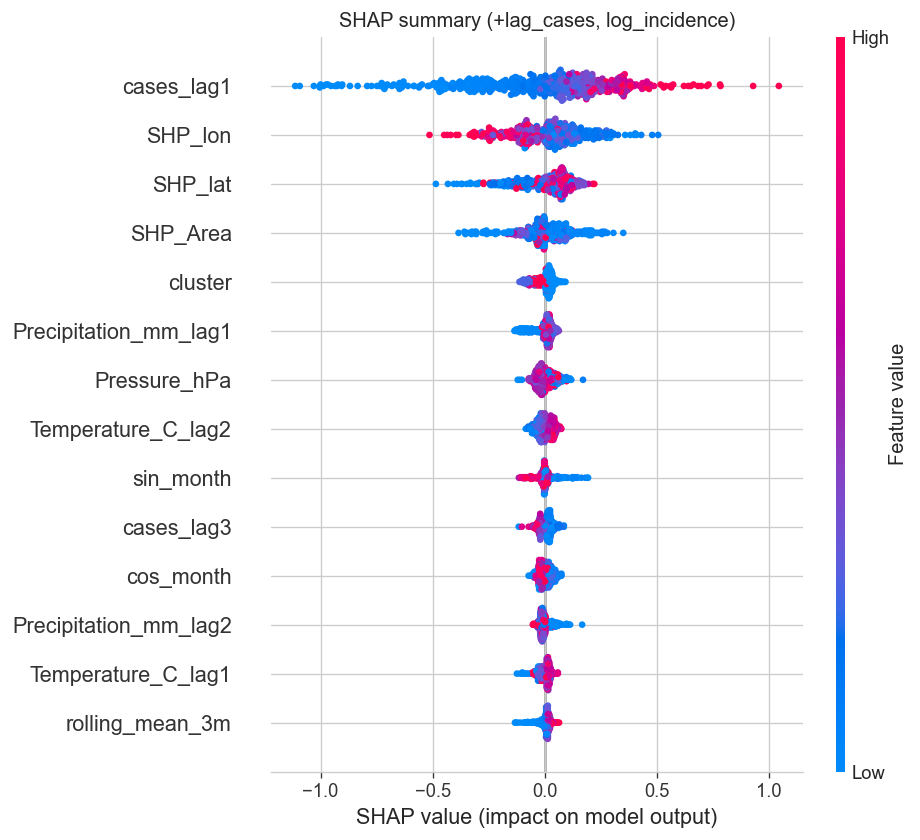

[Figure 14] saved → 2_FIGURES\regenerated\fig4_shap_lag.png   — SHAP summary, +lag_cases regressor


In [22]:
# ══ THESIS FIGURE 14 · fig4_shap_lag.png ════════════════════════════════════
# SHAP summary for the +lag_cases regression model.
Xl = _X(FEAT_LAG)
reg_shap = make_xgb_reg(n_estimators=400)
reg_shap.fit(Xl, dfm['log_incidence'])

samp = Xl.sample(min(500, len(Xl)), random_state=SEED)
sv, _ = shap_values_xgb(reg_shap, samp)

plt.figure()
shap.summary_plot(sv, samp, show=False, max_display=14)
plt.title('SHAP summary (+lag_cases, log_incidence)', fontsize=12)
plt.tight_layout()
save_fig('fig4_shap_lag.png', 14, '— SHAP summary, +lag_cases regressor')

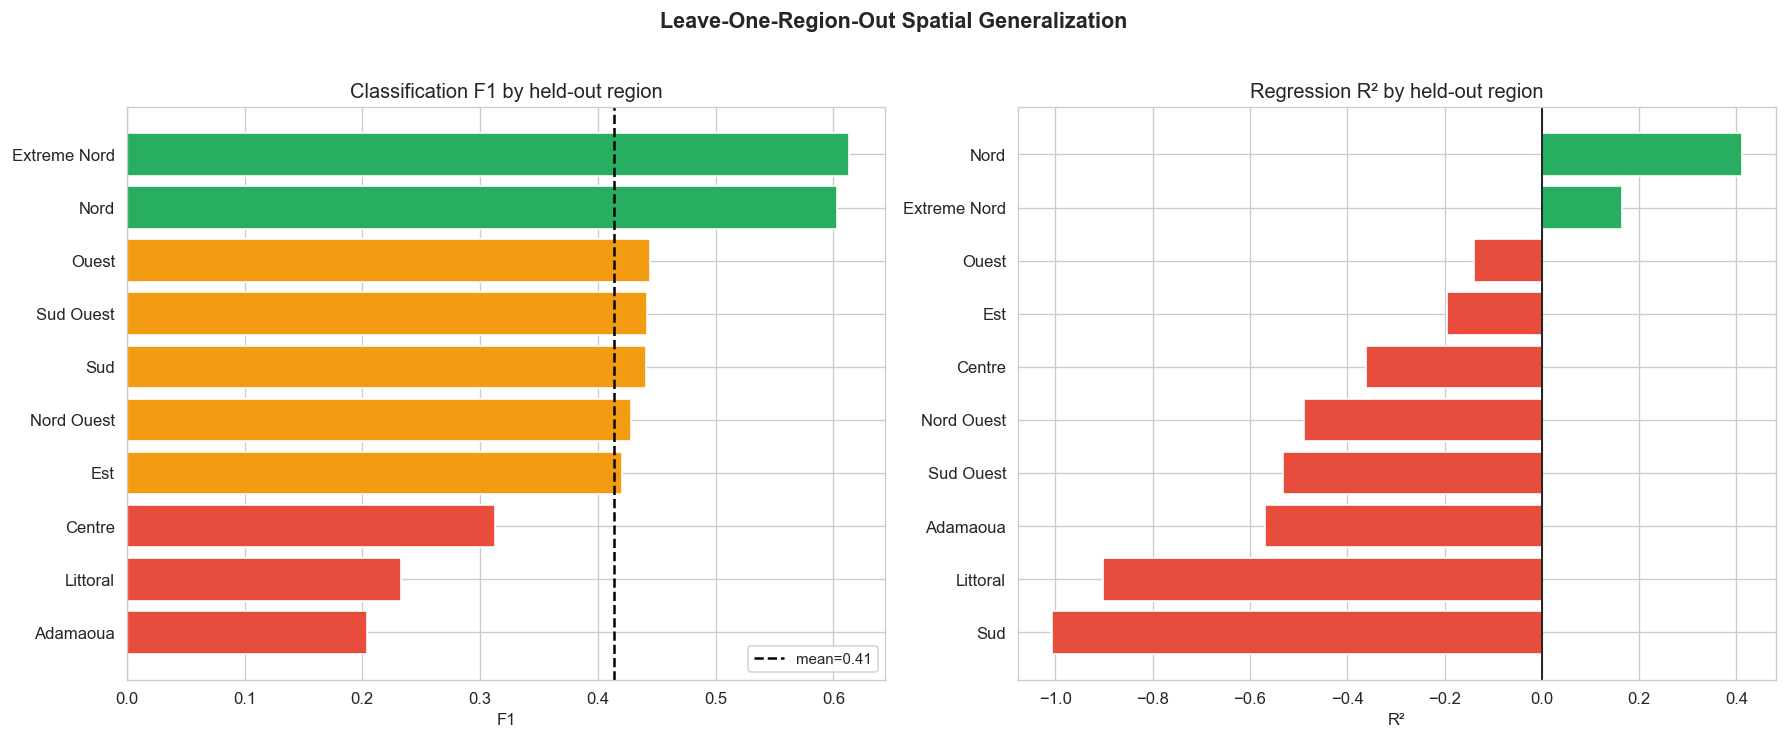

[Figure 15] saved → 2_FIGURES\regenerated\fig5_loro_lag.png   — LORO mean F1=0.414  mean R²=-0.362


,Region,F1,R2
0,Adamaoua,0.204,-0.570
1,Centre,0.313,-0.362
2,Est,0.421,-0.196
3,Extreme Nord,0.613,0.164
4,Littoral,0.233,-0.902
5,Nord,0.603,0.410
6,Nord Ouest,0.428,-0.490
7,Ouest,0.444,-0.140
8,Sud,0.441,-1.006
9,Sud Ouest,0.442,-0.533


In [23]:
# ══ THESIS FIGURE 15 · fig5_loro_lag.png ════════════════════════════════════
# Leave-One-Region-Out (ENG features): spatial generalisation is the hard limit.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
s1 = loro.sort_values('F1')
cc = ['#27ae60' if v >= 0.5 else '#f39c12' if v >= 0.35 else '#e74c3c'
      for v in s1['F1']]
axes[0].barh(s1['Region'], s1['F1'], color=cc, edgecolor='white')
axes[0].axvline(loro['F1'].mean(), color='black', ls='--',
                label=f"mean={loro['F1'].mean():.2f}")
axes[0].set_xlabel('F1'); axes[0].set_title('Classification F1 by held-out region')
axes[0].legend(fontsize=9)

s2 = loro.sort_values('R2')
cc2 = ['#27ae60' if v >= 0 else '#e74c3c' for v in s2['R2']]
axes[1].barh(s2['Region'], s2['R2'], color=cc2, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('R²'); axes[1].set_title('Regression R² by held-out region')
plt.suptitle('Leave-One-Region-Out Spatial Generalization',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fig5_loro_lag.png', 15,
         f"— LORO mean F1={loro['F1'].mean():.3f}  mean R²={loro['R2'].mean():.3f}")
display(loro.round(3))

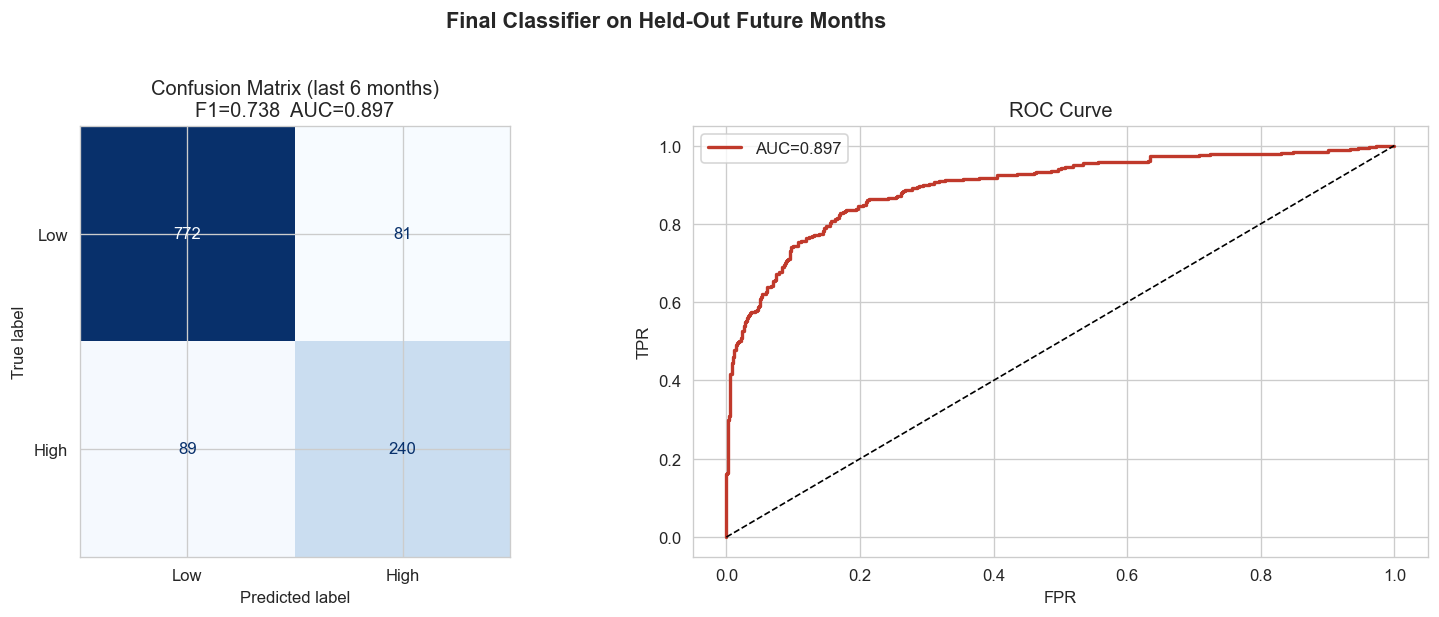

[Figure 16] saved → 2_FIGURES\regenerated\fig6_confusion_lag.png   — confusion matrix + ROC, future months


In [24]:
# ══ THESIS FIGURE 16 · fig6_confusion_lag.png ═══════════════════════════════
# The +lag_cases classifier on genuinely held-out future months (oracle lags).
dates = sorted(dfm['date'].unique())
CUT   = dates[-6]                     # reused by Figure 17
tr, te = dfm['date'] < CUT, dfm['date'] >= CUT
Xtr = dfm.loc[tr, FEAT_LAG].fillna(dfm[FEAT_LAG].median())
Xte = dfm.loc[te, FEAT_LAG].fillna(dfm[FEAT_LAG].median())
sw  = (dfm.loc[tr, 'high'] == 0).sum() / (dfm.loc[tr, 'high'] == 1).sum()

clf6 = make_xgb_clf(sw)
clf6.fit(Xtr, dfm.loc[tr, 'high'])
yp, yproba, yt = clf6.predict(Xte), clf6.predict_proba(Xte)[:, 1], dfm.loc[te, 'high']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(yt, yp, display_labels=['Low', 'High'],
                                        cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title(f'Confusion Matrix (last 6 months)\n'
                  f'F1={f1_score(yt, yp):.3f}  AUC={roc_auc_score(yt, yproba):.3f}')
fpr, tpr, _ = roc_curve(yt, yproba)
axes[1].plot(fpr, tpr, color='#c0392b', lw=2,
             label=f'AUC={roc_auc_score(yt, yproba):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()
plt.suptitle('Final Classifier on Held-Out Future Months',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fig6_confusion_lag.png', 16, '— confusion matrix + ROC, future months')

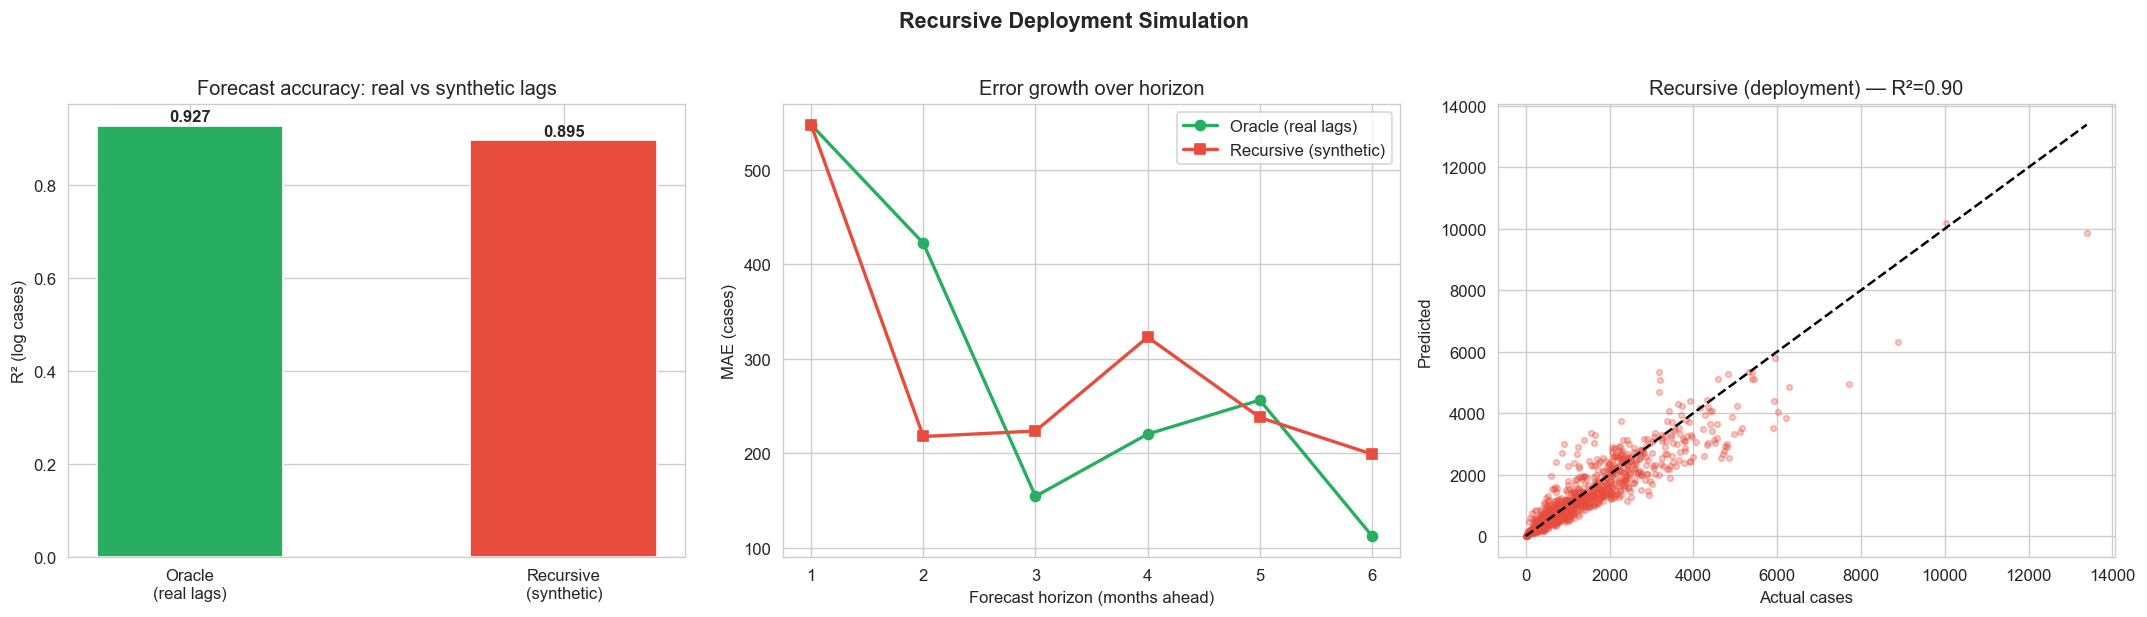

[Figure 17] saved → 2_FIGURES\regenerated\fig7_recursive.png   — oracle R²=0.927 vs recursive R²=0.895
Oracle R²=0.927 MAE=285 | Recursive R²=0.895 MAE=291 | ΔR²=+0.032


In [25]:
# ══ THESIS FIGURE 17 · fig7_recursive.png ═══════════════════════════════════
# Recursive deployment simulation: the model consumes its OWN predictions as
# cases_lag, which is the real situation with sensors but no case surveillance.
train = dfm[dfm['date'] < CUT].copy()
Xtr2  = train[FEAT_LAG].fillna(train[FEAT_LAG].median())
reg_lag = make_xgb_reg(n_estimators=400)
reg_lag.fit(Xtr2, train['log_cases'])

med, test_dates = train[FEAT_LAG].median(), dates[-6:]
oracle, rec = [], []
for dist in dfm['district'].unique():
    s = dfm[dfm['district'] == dist].sort_values('date').set_index('date')
    if not all(d in s.index for d in test_dates):
        continue
    ph = s[s.index < CUT]['cases'].tolist()      # case history, then predictions
    for d in test_dates:
        row = s.loc[d]
        # oracle: real lags
        Xo = pd.DataFrame([row[FEAT_LAG]]).fillna(med)[FEAT_LAG]
        oracle.append((row['cases'], np.expm1(reg_lag.predict(Xo)[0]), dist))
        # recursive: synthetic lags from the model's own history
        fr = row[FEAT_LAG].copy()
        fr['cases_lag1'] = ph[-1] if len(ph) >= 1 else med['cases_lag1']
        fr['cases_lag2'] = ph[-2] if len(ph) >= 2 else med['cases_lag2']
        fr['cases_lag3'] = ph[-3] if len(ph) >= 3 else med['cases_lag3']
        fr['rolling_mean_3m'] = np.mean(ph[-3:]) if len(ph) >= 1 else med['rolling_mean_3m']
        Xr = pd.DataFrame([fr]).fillna(med)[FEAT_LAG]
        pr = np.expm1(reg_lag.predict(Xr)[0])
        rec.append((row['cases'], pr, dist)); ph.append(pr)

o = pd.DataFrame(oracle, columns=['actual', 'pred', 'district'])
r = pd.DataFrame(rec,    columns=['actual', 'pred', 'district'])
o_r2 = r2_score(np.log1p(o.actual), np.log1p(o.pred)); o_mae = mean_absolute_error(o.actual, o.pred)
r_r2 = r2_score(np.log1p(r.actual), np.log1p(r.pred)); r_mae = mean_absolute_error(r.actual, r.pred)
o['h'] = o.groupby('district').cumcount() + 1
r['h'] = r.groupby('district').cumcount() + 1
oh = o.groupby('h').apply(lambda g: mean_absolute_error(g.actual, g.pred))
rh = r.groupby('h').apply(lambda g: mean_absolute_error(g.actual, g.pred))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(['Oracle\n(real lags)', 'Recursive\n(synthetic)'], [o_r2, r_r2],
            color=[CLR['oracle'], CLR['recursive']], edgecolor='white', width=0.5)
axes[0].set_ylabel('R² (log cases)')
axes[0].set_title('Forecast accuracy: real vs synthetic lags')
for i, v in enumerate([o_r2, r_r2]):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].plot(oh.index, oh.values, 'o-', color=CLR['oracle'], lw=2, label='Oracle (real lags)')
axes[1].plot(rh.index, rh.values, 's-', color=CLR['recursive'], lw=2, label='Recursive (synthetic)')
axes[1].set_xlabel('Forecast horizon (months ahead)'); axes[1].set_ylabel('MAE (cases)')
axes[1].set_title('Error growth over horizon'); axes[1].legend()
axes[2].scatter(r.actual, r.pred, alpha=0.3, s=12, color=CLR['recursive'])
lim = [0, max(r.actual.max(), r.pred.max())]; axes[2].plot(lim, lim, 'k--')
axes[2].set_xlabel('Actual cases'); axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Recursive (deployment) — R²={r_r2:.2f}')
plt.suptitle('Recursive Deployment Simulation', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('fig7_recursive.png', 17,
         f'— oracle R²={o_r2:.3f} vs recursive R²={r_r2:.3f}')
print(f'Oracle R²={o_r2:.3f} MAE={o_mae:.0f} | Recursive R²={r_r2:.3f} '
      f'MAE={r_mae:.0f} | ΔR²={o_r2-r_r2:+.3f}')

---
## Part 5 · Explainability — native feature importance across both tasks

*Thesis Figure 18 · originally `files (2)/malaria_full_protocol.ipynb`, Phase 9 (cell 21)*

The source cell displayed this figure inline — it never called `savefig`, so the
`fig03/` copy was exported by hand. It uses the **Optuna-tuned** XGBoost regressor
and classifier from Phase 8, refit on all data with the 16 ENG features.

Rather than re-running the 25-trial Optuna search (~20 min for an identical
outcome), the tuned hyper-parameters recorded in `files (2)/artifacts.json` are
loaded and the models refit directly. Those recorded parameters and scores match
the source notebook's stored output exactly (reg R² 0.769 KFold / 0.628
TimeSeriesSplit; clf F1 0.725 / 0.655). Set `RERUN_OPTUNA = True` in Part 0 to
redo the search instead.

In [26]:
# ── Recover the Phase-8 tuned models ────────────────────────────────────────
# The protocol notebook drops only the climate-lag NaNs (not the case lags),
# giving 7 092 rows — a different frame from Part 4's dfm.
df_model = (panel.dropna(subset=['Temperature_C_lag1', 'Temperature_C_lag2'])
            .copy().sort_values('date').reset_index(drop=True))
Xr = df_model[FEAT_ENG].fillna(df_model[FEAT_ENG].median()).reset_index(drop=True)
yr = df_model['log_incidence'].reset_index(drop=True)
yc = df_model['high'].reset_index(drop=True)
spw_proto = (yc == 0).sum() / (yc == 1).sum()

print(f'Protocol frame: {df_model.shape} | scale_pos_weight={spw_proto:.3f}')

if RERUN_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def _suggest(trial):
        return dict(n_estimators=trial.suggest_int('n_estimators', 200, 700, step=100),
                    max_depth=trial.suggest_int('max_depth', 3, 8),
                    learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                    subsample=trial.suggest_float('subsample', 0.6, 1.0),
                    colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0))

    def _obj_reg(trial):
        p = _suggest(trial); sc = []
        for tr, te in KFold(5, shuffle=True, random_state=SEED).split(Xr):
            m = make_xgb_reg(**p); m.fit(Xr.iloc[tr], yr.iloc[tr])
            sc.append(r2_score(yr.iloc[te], m.predict(Xr.iloc[te])))
        return np.mean(sc)

    def _obj_clf(trial):
        p = _suggest(trial); sc = []
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xr, yc):
            m = make_xgb_clf(spw_proto, **p); m.fit(Xr.iloc[tr], yc.iloc[tr])
            sc.append(f1_score(yc.iloc[te], m.predict(Xr.iloc[te]), zero_division=0))
        return np.mean(sc)

    s_r = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=SEED))
    s_r.optimize(_obj_reg, n_trials=25)
    s_c = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=SEED))
    s_c.optimize(_obj_clf, n_trials=25)
    reg_params, clf_params = s_r.best_params, s_c.best_params
    print(f'Optuna re-run — reg R²={s_r.best_value:.4f}  clf F1={s_c.best_value:.4f}')
else:
    art = json.load(open(data('artifacts.json'), encoding='utf-8'))
    reg_params, clf_params = art['reg_best_params'], art['clf_best_params']
    print('Loaded recorded Optuna parameters from', data('artifacts.json').name)
    print('  recorded scores:', json.dumps(art['scores']))

print('  reg:', reg_params)
print('  clf:', clf_params)

reg_tuned = make_xgb_reg(**reg_params); reg_tuned.fit(Xr, yr)
clf_tuned = make_xgb_clf(spw_proto, **clf_params); clf_tuned.fit(Xr, yc)
print('Tuned models refit on all data.')

Protocol frame: (7092, 32) | scale_pos_weight=2.916
Loaded recorded Optuna parameters from artifacts.json
  recorded scores: {"regression": {"KFold_R2": 0.7694215854321766, "TimeSeriesSplit_R2": 0.6278734525377858}, "classification": {"KFold_F1": 0.7253478500759438, "TimeSeriesSplit_F1": 0.6552007771262525}}
  reg: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.062039098471647035, 'subsample': 0.715068312794609, 'colsample_bytree': 0.8165253555750989}
  clf: {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.10954014241706547, 'subsample': 0.9362148766913247, 'colsample_bytree': 0.8307796695558711}
Tuned models refit on all data.


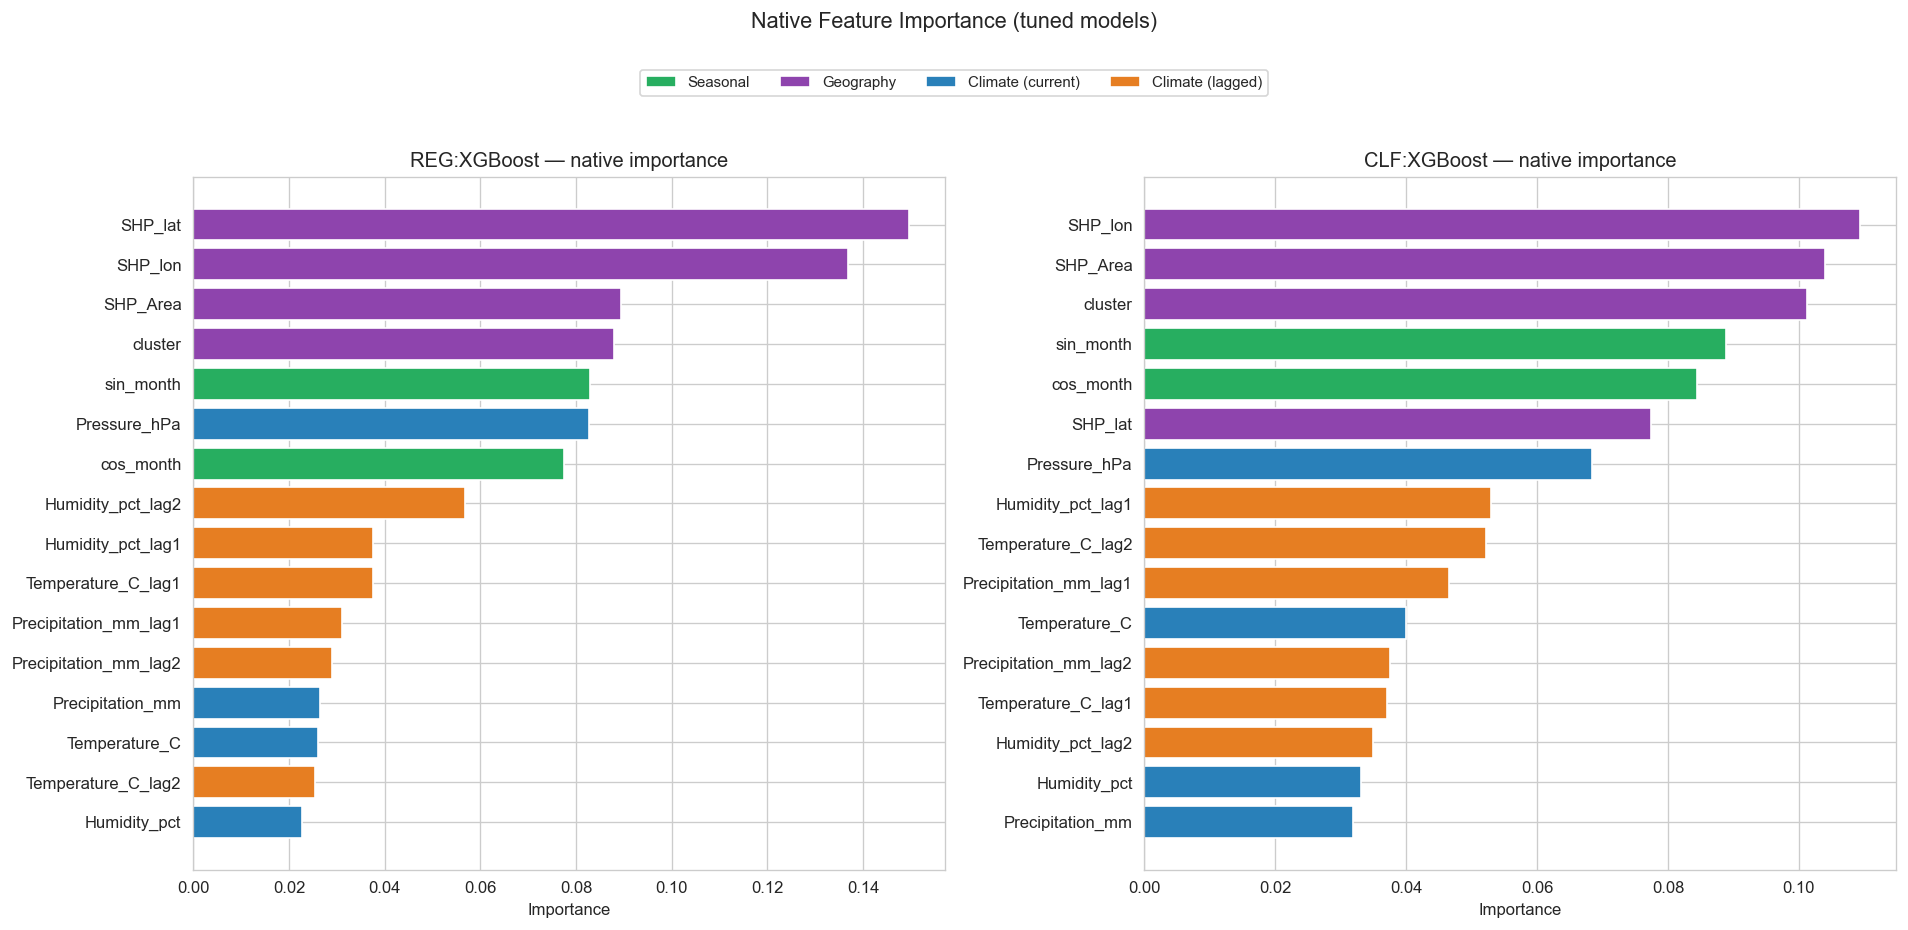

[Figure 18] saved → 2_FIGURES\regenerated\native_importance_crosstask.png   — tuned REG + CLF importance
Top 6 drivers (tuned regressor):
  SHP_lat                    0.1497  [Geography]
  SHP_lon                    0.1369  [Geography]
  SHP_Area                   0.0895  [Geography]
  cluster                    0.0879  [Geography]
  sin_month                  0.0829  [Seasonal]
  Pressure_hPa               0.0827  [Climate]


In [27]:
# ══ THESIS FIGURE 18 · native_importance_crosstask.png ══════════════════════
# Native gain importance of the tuned regressor and classifier side by side,
# coloured by feature family.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, m, title in [(axes[0], reg_tuned, 'REG:XGBoost — native importance'),
                     (axes[1], clf_tuned, 'CLF:XGBoost — native importance')]:
    imp = pd.Series(m.feature_importances_, index=FEAT_ENG).sort_values()
    ax.barh(imp.index, imp.values, color=[feat_color(f) for f in imp.index])
    ax.set_title(title); ax.set_xlabel('Importance')

fig.legend(handles=[Patch(facecolor='#27ae60', label='Seasonal'),
                    Patch(facecolor='#8e44ad', label='Geography'),
                    Patch(facecolor='#2980b9', label='Climate (current)'),
                    Patch(facecolor='#e67e22', label='Climate (lagged)')],
           loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.04), fontsize=9)
plt.suptitle('Native Feature Importance (tuned models)', fontsize=13, y=1.10)
plt.tight_layout()
save_fig('native_importance_crosstask.png', 18, '— tuned REG + CLF importance')

top = pd.Series(reg_tuned.feature_importances_, index=FEAT_ENG).nlargest(6)
print('Top 6 drivers (tuned regressor):')
for f, v in top.items():
    grp = ('Geography' if any(s in f for s in ['lat', 'lon', 'Area', 'cluster'])
           else 'Seasonal' if 'month' in f else 'Climate')
    print(f'  {f:<26} {v:.4f}  [{grp}]')

---
## Part 6 · Deployment — what drives the 2026 Yaoundé prediction

*Thesis Figure 19 · **reconstructed** — no surviving notebook produces it*

`fig03/pred2026_shap.png` is the one thesis figure with no `savefig` call anywhere
in the repository and no byte-identical copy on disk. Its content identifies it
unambiguously, though:

* title **"SHAP — Drivers of the Predicted Cases (NO-LAG model)"** → the target is
  **cases**, and the model is the 16-feature climate-only regressor;
* panels **May 2026** and **June 2026** → the Yaoundé deployment window;
* the 16 features shown are exactly `FEAT_NOLAG` from
  `files (11)/malaria_deployment.ipynb`, whose `regressor_nolag.joblib` is the only
  saved model in the project that predicts `log_cases` from those 16 features.

The cell below rebuilds it from those components: the saved NO-LAG regressor, the
2026 Yaoundé climate, and the Biyem Assi static row. Because the model file is
loaded (not retrained) the SHAP values are exactly those of the deployed model.

**The reconstruction was checked against the published PNG and matches**: the top
five drivers, their order and their magnitudes agree in both panels
(`SHP_Area` ≈ 0.66, `cluster` ≈ 0.6, `SHP_lat` ≈ 0.45, `SHP_lon` ≈ 0.12,
`Pressure_hPa` ≈ 0.09), and every contribution agrees in sign. Only a few
near-zero features below rank 5 swap places. This confirms the source model was
identified correctly.

  [shap fallback] could not convert string to float: '[6.570336E0]'  → using xgboost pred_contribs


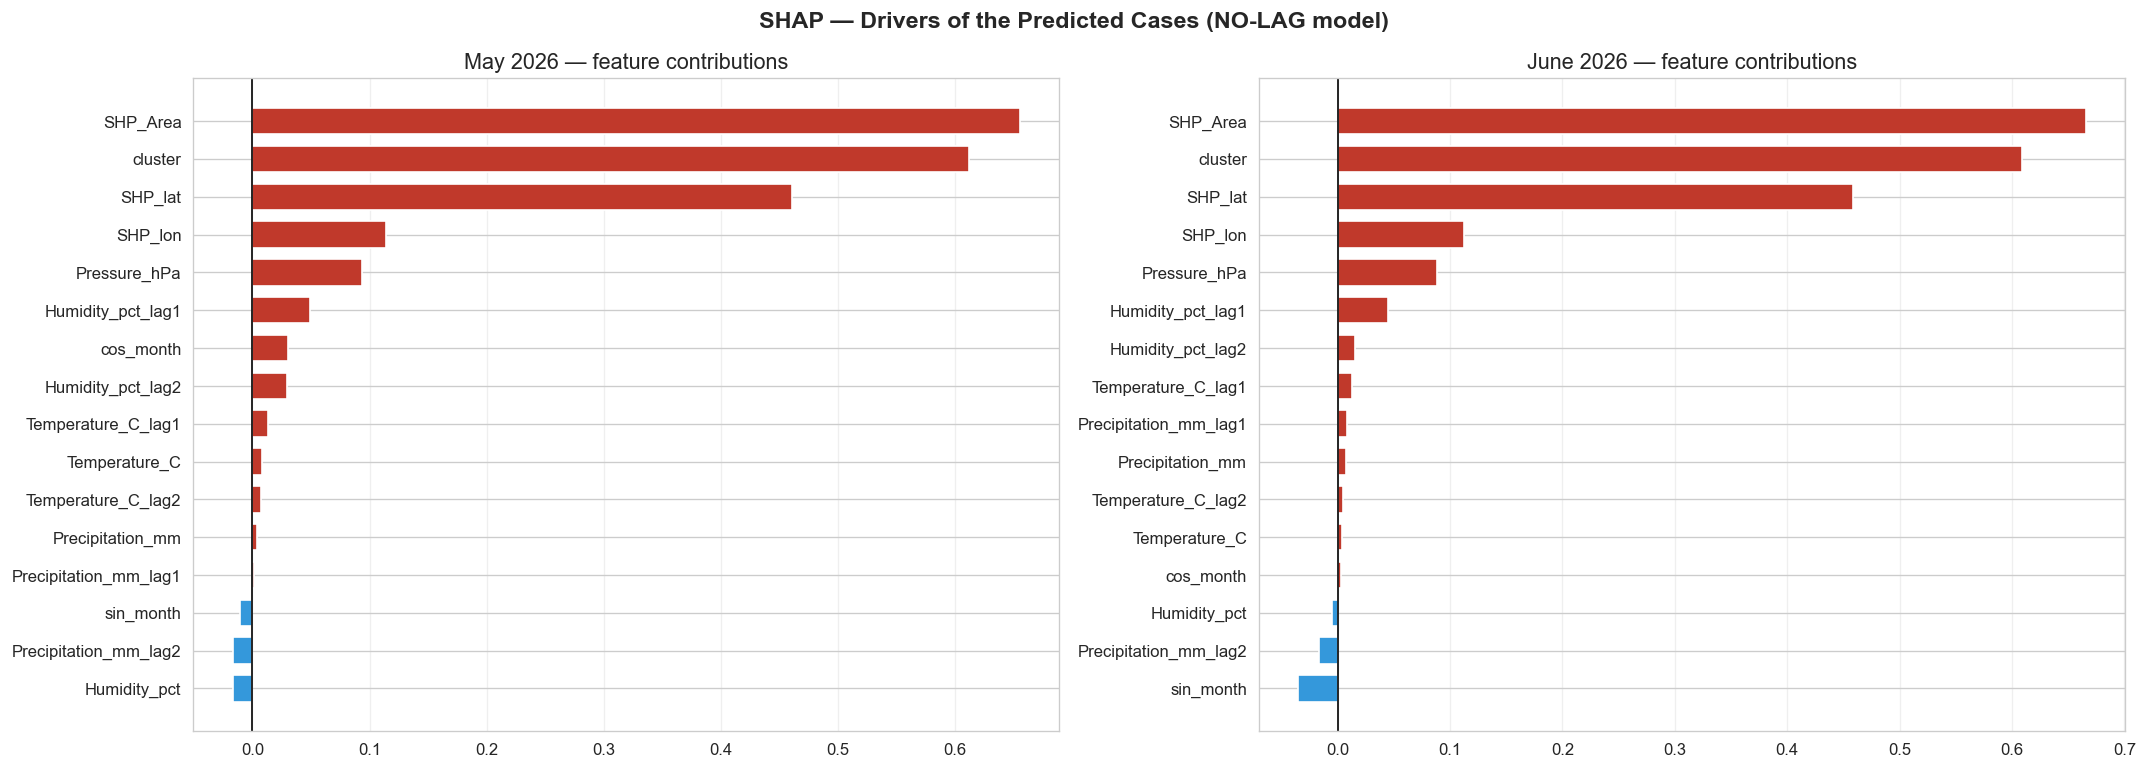

[Figure 19] saved → 2_FIGURES\regenerated\pred2026_shap.png   — reconstructed deployment SHAP
SHAP base value (mean log_cases at training): 6.5678 ≈ 711 cases
   May 2026 →     5448 cases (13.28/1000)  threshold=14.28
  June 2026 →     5139 cases (12.52/1000)  threshold=14.28


In [28]:
# ══ THESIS FIGURE 19 · pred2026_shap.png ════════════════════════════════════
# Reconstructed: SHAP drivers of the NO-LAG regressor's May/June 2026 forecast.
reg_nolag = joblib.load(BUNDLE_DIR / 'regressor_nolag.joblib')
static    = pd.read_csv(BUNDLE_DIR / 'district_static.csv')
biyem     = static[static['district'] == 'Biyem Assi'].iloc[0]

# Monthly aggregation of the deployment-window climate
dep2 = dep.rename(columns={'Humidity': 'Humidity_pct'}).copy()
dep2['month'] = dep2['Date'].dt.month
monthly26 = dep2.groupby('month').agg(
    Temperature_C=('Temperature_C', 'mean'),
    Humidity_pct=('Humidity_pct', 'mean'),
    Pressure_hPa=('Pressure_hPa', 'mean'),
    Precipitation_mm=('Precipitation_mm', 'sum')).reset_index()

# Feature rows for May (5) and June (6); Feb–Apr supply the climate lags
MONTH_LONG = {4: 'April', 5: 'May', 6: 'June'}
rows = []
for _, row in monthly26[monthly26['month'] >= 5].iterrows():
    m = int(row['month'])
    lag1 = monthly26[monthly26['month'] == m - 1].iloc[0]
    lag2 = monthly26[monthly26['month'] == m - 2].iloc[0]
    rows.append({
        'month': m,
        'sin_month': np.sin(2*np.pi*m/12), 'cos_month': np.cos(2*np.pi*m/12),
        'SHP_lat': biyem['SHP_lat'], 'SHP_lon': biyem['SHP_lon'],
        'SHP_Area': biyem['SHP_Area'], 'cluster': biyem['cluster'],
        'Temperature_C': row['Temperature_C'], 'Humidity_pct': row['Humidity_pct'],
        'Pressure_hPa': row['Pressure_hPa'], 'Precipitation_mm': row['Precipitation_mm'],
        'Temperature_C_lag1': lag1['Temperature_C'],
        'Temperature_C_lag2': lag2['Temperature_C'],
        'Precipitation_mm_lag1': lag1['Precipitation_mm'],
        'Precipitation_mm_lag2': lag2['Precipitation_mm'],
        'Humidity_pct_lag1': lag1['Humidity_pct'],
        'Humidity_pct_lag2': lag2['Humidity_pct'],
    })
X26 = pd.DataFrame(rows)[FEAT_ENG]            # FEAT_ENG == FEAT_NOLAG

pred_log_cases = reg_nolag.predict(X26)
pred_cases     = np.expm1(pred_log_cases)
sv26, base26   = shap_values_xgb(reg_nolag, X26)

RED, BLUE = '#c0392b', '#3498db'
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
for idx, ax in enumerate(axes):
    s = pd.Series(sv26[idx], index=FEAT_ENG).sort_values(ascending=False)
    ax.barh(range(len(s)), s.values,
            color=[RED if v > 0 else BLUE for v in s.values],
            edgecolor='white', height=0.7)
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=10)
    ax.invert_yaxis()
    ax.axvline(0, color='black', lw=1)
    ax.set_title(f'{MONTH_LONG[int(rows[idx]["month"])]} 2026 — feature contributions',
                 fontsize=13)
    ax.grid(True, axis='x', alpha=0.3); ax.set_axisbelow(True)

fig.suptitle('SHAP — Drivers of the Predicted Cases (NO-LAG model)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('pred2026_shap.png', 19, '— reconstructed deployment SHAP')

print(f'SHAP base value (mean log_cases at training): {base26:.4f} '
      f'≈ {np.expm1(base26):.0f} cases')
for i, rw in enumerate(rows):
    inc = pred_cases[i] / biyem['p_totale'] * 1000
    print(f'{MONTH_LONG[int(rw["month"])]:>6} 2026 → {pred_cases[i]:8.0f} cases '
          f'({inc:5.2f}/1000)  threshold={biyem["threshold_75"]:.2f}')

---
## Summary

In [29]:
# ── Regeneration report ─────────────────────────────────────────────────────
log = pd.DataFrame(FIGURE_LOG)
expected = 19
print(f'Regenerated {len(log)}/{expected} thesis figures → {OUT_DIR}')
display(log)

if THESIS_FIGS.is_dir():
    missing = sorted({p.name for p in THESIS_FIGS.glob('*.png')} -
                     {p.name for p in OUT_DIR.glob('*.png')})
    if missing:
        print('\nNOT regenerated:', missing)
    else:
        print(f'\nEvery file in {THESIS_FIGS.name}/ has a regenerated counterpart.')
else:
    print(f'\n(reference figures not found at {THESIS_FIGS} — skipping cross-check)')

Regenerated 19/19 thesis figures → d:\ECOLE\ENSPY\Projet\mal_proj\malaria_thesis_package\2_FIGURES\regenerated


,n,file,note
0,1,yde_climate_2019_2022.png,— training-period climate
1,2,yde_climatology.png,"— bimodal peaks: months [9, 10]"
2,3,yde_climate_2026.png,— deployment-window climate
3,4,yde_2026_vs_hist.png,— 2026 vs historical envelope
4,5,yde_target_districts.png,— cases & incidence per district
5,6,yde_target_threshold.png,— Low/High months vs threshold
6,7,yde_target_distribution.png,— histogram + boxplot vs threshold
7,8,yde_climate_malaria.png,— rainfall / incidence overlay
8,9,yde_lag_correlation.png,— lagged climate–incidence correlation
9,10,yde_seasonal_cases.png,— seasonal incidence cycle



Every file in thesis_figures/ has a regenerated counterpart.


### What was reproduced, and how faithfully

| Group | Figures | Fidelity |
|---|---|---|
| Yaoundé climate EDA | 1–4 | Code is verbatim from `te/yaounde_climate_eda.ipynb`; identical inputs → identical output. |
| Yaoundé target EDA | 5–10 | Plotting code verbatim from `te/yaounde_target_eda.ipynb`; its missing `pipeline_lib.build()` is replaced by `build_panel()`, which implements the same fusion. Figures 5–10 in `fig03/` are byte-identical to `te/`, so this is the exact pipeline. |
| Modelling results | 11–17 | Code verbatim from `files (2)/malaria_showcase_lag.ipynb`, all seeds fixed at 42. The LORO computation is factored into one helper the two figures share (the source computed it twice with identical parameters). |
| Native importance | 18 | Same tuned models, refit from the Optuna parameters recorded in `artifacts.json` instead of re-searching. |
| Deployment SHAP | 19 | **Reconstructed**, not copied — see Part 6. Model weights are the saved ones, so the SHAP values are exact; the cosmetic layout is inferred from the published PNG. |

### Known deviations

1. **Figure 19 layout is inferred.** The numbers are the deployed model's; the
   axis styling was reconstructed from the image in `fig03/`.
2. **Figures 1–4 differ in file size from the `te/` copies** even though they come
   from the same notebook — the `fig03/` versions are from a later re-run. Content
   is equivalent; exact byte-equality is not expected.
3. **`RERUN_OPTUNA = False`** by default. The recorded parameters reproduce the
   published Figure 18; a fresh search may land on slightly different values.
4. **SHAP/XGBoost compatibility.** With `shap <= 0.47` and `xgboost >= 3.0`,
   `shap.TreeExplainer` raises `ValueError: could not convert string to float:
   '[2.12E0]'` because xgboost now serialises `base_score` as a one-element array.
   `shap_values_xgb()` catches exactly that and falls back to xgboost's own
   `pred_contribs=True`, which runs the same TreeSHAP algorithm internally.
   Values are identical to float precision, so Figures 14 and 19 are unaffected.